# COCOStat: Sri Lanka Coconut Market — Comprehensive Analytical Report
**Dataset Coverage:** 2015 – 2025 | **Scope:** Price Clustering, Elasticity, SARIMAX Forecasting, Production, Trade & Global Benchmarks

---

# **Environment Setup**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0f1117',
    'axes.facecolor':    '#1a1d27',
    'axes.edgecolor':    '#3a3d4d',
    'axes.labelcolor':   '#e0e0e0',
    'axes.titlecolor':   '#ffffff',
    'xtick.color':       '#aaaaaa',
    'ytick.color':       '#aaaaaa',
    'text.color':        '#e0e0e0',
    'grid.color':        '#2a2d3a',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'legend.facecolor':  '#1a1d27',
    'legend.edgecolor':  '#3a3d4d',
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'figure.dpi':        130,
})

PALETTE = {
    'Stable':  '#2ecc71',
    'Warning': '#f39c12',
    'Crisis':  '#e74c3c',
    'forecast':'#00bfff',
    'actual':  '#a78bfa',
    'ci':      '#00bfff',
}

from google.colab import files
uploaded = files.upload()
if uploaded:
    pass


Saving Dataset.xlsx to Dataset.xlsx


---
## 1. Data Ingestion & Quality Audit

In [52]:
DATA_PATH = 'Dataset.xlsx'

# ── Helper: flexible sheet name matcher ─────────────────────────────────────
def get_sheet(target):
    xls = pd.ExcelFile(DATA_PATH)
    for sheet in xls.sheet_names:
        if target.lower() in sheet.lower():
            return sheet
    raise ValueError(f"No matching sheet found for '{target}'. Available: {xls.sheet_names}")


def _load(sheet_key, cols):
    sheet = get_sheet(sheet_key)  # auto-match sheet name
    df = pd.read_excel(DATA_PATH, sheet_name=sheet, header=0)

    df = df.iloc[:, :len(cols)]
    df.columns = cols

    # Clean Year column
    df = df[pd.to_numeric(df['Year'], errors='coerce').notna()].copy()
    df['Year'] = df['Year'].astype(int)

    return df


# ── Load all sheets ─────────────────────────────────────────────────────────
df_weekly = _load('weekly', [
    'Year','Month','Week_Date','Offered_Nuts','Sold_Nuts',
    'Avg_Price','Palm_Oil_Price','Inflation','CSE'
])

df_prod = _load('production', [
    'Year','Total_Production','Copra','VCO','DC',
    'Coconut_Milk','CMP','Fresh_Nuts_Local','Seed_Coconut'
])

df_export = _load('export_products', [
    'Year','DC_MT','CocoOil_MT','CMP_MT','Coir_MT',
    'FreshNuts_1000','Copra_MT','CocoMilk_MT',
    'CocoCream_MT','Total_Export_MT'
])

df_global = _load('global_benchmarks', [
    'Year','World_CocoOil_USD','SL_Yield','Land_Ha',
    'Land_Ac','SL_Avg_Price','YoY_Price_Change'
])

df_weather = _load('weather', [
    'Year','Month','Rainfall','Temperature',
    'Yield_Index','Drought_Flag','Lag3_Rain'
])

df_gcmp = _load('global_comparison', [
    'Year','SL','Indonesia','Philippines',
    'India','Vietnam','SL_vs_World_Avg'
])

df_dest = _load('destinations', [
    'Year','USA','UK','Germany','Australia',
    'Netherlands','Japan','Canada','UAE','Others','Total'
])


# ── WEEKLY time-series ──────────────────────────────────────────────────────
df_weekly['Date'] = pd.to_datetime(df_weekly['Week_Date'], errors='coerce')
df_weekly = df_weekly.sort_values('Date').reset_index(drop=True)

df_weekly['Sell_Through_Rate'] = (
    df_weekly['Sold_Nuts'] / df_weekly['Offered_Nuts']
)


# ── Data quality summary ────────────────────────────────────────────────────
quality_data = {
    'Sheet': [
        'Weekly Auction','Production','Export Products',
        'Global Benchmarks','Weather/Harvest',
        'Global Comparison','Export Destinations'
    ],
    'Rows': [
        len(df_weekly), len(df_prod), len(df_export),
        len(df_global), len(df_weather),
        len(df_gcmp), len(df_dest)
    ],
    'Period': [
        '2015-2025','2015-2025','2013-2025',
        '2015-2025','2015-2025',
        '2015-2025','2015-2025'
    ],
    'Missing_%': [
        round(df_weekly.isnull().mean().mean()*100,1),
        round(df_prod.isnull().mean().mean()*100,1),
        round(df_export.isnull().mean().mean()*100,1),
        round(df_global.isnull().mean().mean()*100,1),
        round(df_weather.isnull().mean().mean()*100,1),
        round(df_gcmp.isnull().mean().mean()*100,1),
        round(df_dest.isnull().mean().mean()*100,1),
    ]
}

dq = pd.DataFrame(quality_data)
dq.index = dq.index + 1


# ── Output ──────────────────────────────────────────────────────────────────
print('DATA QUALITY AUDIT')
print('=' * 65)
print(dq.to_string(index=True))

print(f'\nWeekly series span: {df_weekly["Date"].min().date()} --> {df_weekly["Date"].max().date()}')
print(f'Total weekly observations: {len(df_weekly)}')

DATA QUALITY AUDIT
                 Sheet  Rows     Period  Missing_%
1       Weekly Auction   517  2015-2025        0.0
2           Production    11  2015-2025        0.0
3      Export Products    13  2013-2025        0.0
4    Global Benchmarks    11  2015-2025        0.0
5      Weather/Harvest   132  2015-2025        8.8
6    Global Comparison    11  2015-2025        0.0
7  Export Destinations    11  2015-2025        0.0

Weekly series span: 2015-01-05 --> 2025-12-18
Total weekly observations: 517


---
## 2. Descriptive Statistics — Weekly Price Series

In [3]:
desc = df_weekly[['Avg_Price','Offered_Nuts','Sold_Nuts','Palm_Oil_Price','Inflation','Sell_Through_Rate']].describe().T
desc.columns = ['Count','Mean','Std','Min','25th','Median','75th','Max']
desc = desc.round(2)

desc['Skewness'] = df_weekly[['Avg_Price','Offered_Nuts','Sold_Nuts','Palm_Oil_Price','Inflation','Sell_Through_Rate']].skew().round(3).values
desc['Kurt'] = df_weekly[['Avg_Price','Offered_Nuts','Sold_Nuts','Palm_Oil_Price','Inflation','Sell_Through_Rate']].kurt().round(3).values
desc['CV_%'] = (desc['Std'] / desc['Mean'] * 100).round(1)

desc.index = ['Avg Price (Rs./1000)', 'Offered Nuts', 'Sold Nuts', 'Palm Oil Price', 'Inflation (%)', 'Sell-Through Rate']
print('DESCRIPTIVE STATISTICS — WEEKLY DATA')
print('=' * 100)
print(desc.to_string())

# Annual averages
annual = df_weekly.groupby('Year').agg(
    Avg_Price=('Avg_Price','mean'),
    Price_Std=('Avg_Price','std'),
    Min_Price=('Avg_Price','min'),
    Max_Price=('Avg_Price','max'),
    Offered_Nuts=('Offered_Nuts','sum'),
    Sold_Nuts=('Sold_Nuts','sum'),
    Avg_STR=('Sell_Through_Rate','mean'),
    Avg_Inflation=('Inflation','mean'),
).round(1)
annual['YoY_Price_Change_%'] = annual['Avg_Price'].pct_change().mul(100).round(1)
print('\n\nANNUAL SUMMARY TABLE')
print('=' * 100)
print(annual.to_string())

DESCRIPTIVE STATISTICS — WEEKLY DATA
                      Count        Mean        Std        Min       25th     Median        75th         Max  Skewness     Kurt    CV_%
Avg Price (Rs./1000)  517.0    56376.46   31125.43   21000.00   31500.00   51655.54    65388.00   181915.68     1.598    2.686    55.2
Offered Nuts          517.0  1051513.30  749413.63    1163.00  645891.00  900000.00  1235876.00  8243806.00     3.601   22.107    71.3
Sold Nuts             517.0   673604.21  305922.31   21569.00  463909.00  650000.00   800000.00  2449692.00     1.137    3.340    45.4
Palm Oil Price        517.0   514884.42  266926.01  214404.76  282916.00  384958.00   736562.50  1334375.00     0.860    0.060    51.8
Inflation (%)         517.0        9.53      16.45      -2.10       2.10       4.10        6.40       70.60     2.695    6.116   172.6
Sell-Through Rate     517.0        2.12      31.87       0.03       0.62       0.73        0.84      725.36    22.736  516.960  1503.3


ANNUAL SUMMARY T

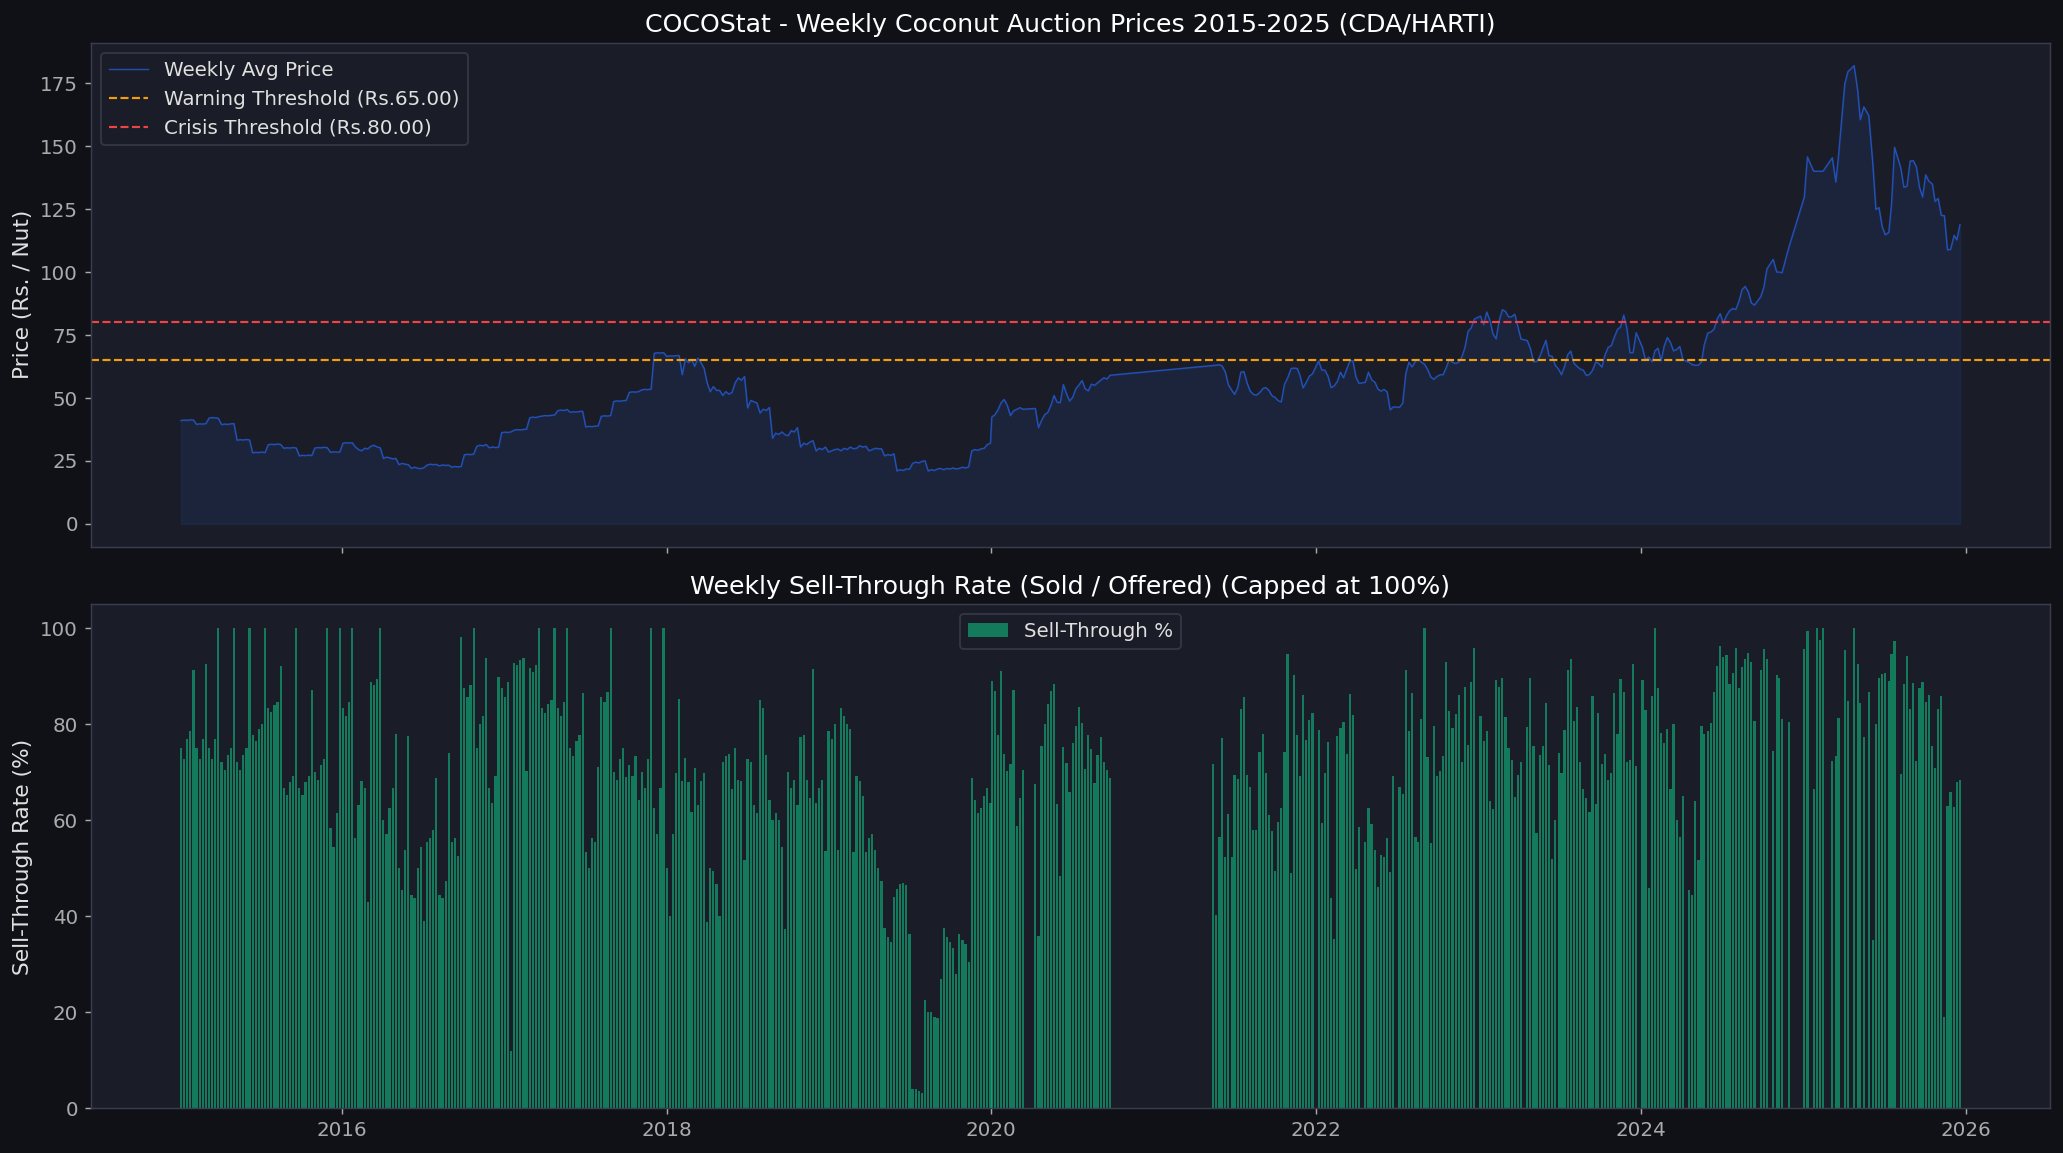

In [4]:
wk = pd.DataFrame(
    {
        'date': df_weekly['Date'],
        'price_1000': df_weekly['Avg_Price'] / 1000,  # Price per 1000 nuts
        'sell_rate': (df_weekly['Sell_Through_Rate'] * 100).clip(upper=100)  # Sell-through rate as percentage, capped at 100%
    }
)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

axes[0].plot(wk['date'], wk['price_1000'], color='#2563eb', lw=0.8, alpha=0.7, label='Weekly Avg Price')
axes[0].fill_between(wk['date'], wk['price_1000'], alpha=0.1, color='#2563eb')
axes[0].axhline(65, color='#f59e0b', lw=1.2, ls='--', label='Warning Threshold (Rs.65.00)')
axes[0].axhline(80, color='#ef4444', lw=1.2, ls='--', label='Crisis Threshold (Rs.80.00)')
axes[0].set_ylabel('Price (Rs. / Nut)')
axes[0].set_title('COCOStat - Weekly Coconut Auction Prices 2015-2025 (CDA/HARTI)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}')) # format as Rs/Nut

axes[1].bar(wk['date'], wk['sell_rate'], color='#10b981', alpha=0.6, width=5, label='Sell-Through %')
axes[1].set_ylabel('Sell-Through Rate (%)')
axes[1].set_title('Weekly Sell-Through Rate (Sold / Offered) (Capped at 100%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('task2_weekly_auction.png', dpi=150, bbox_inches='tight')
plt.show()

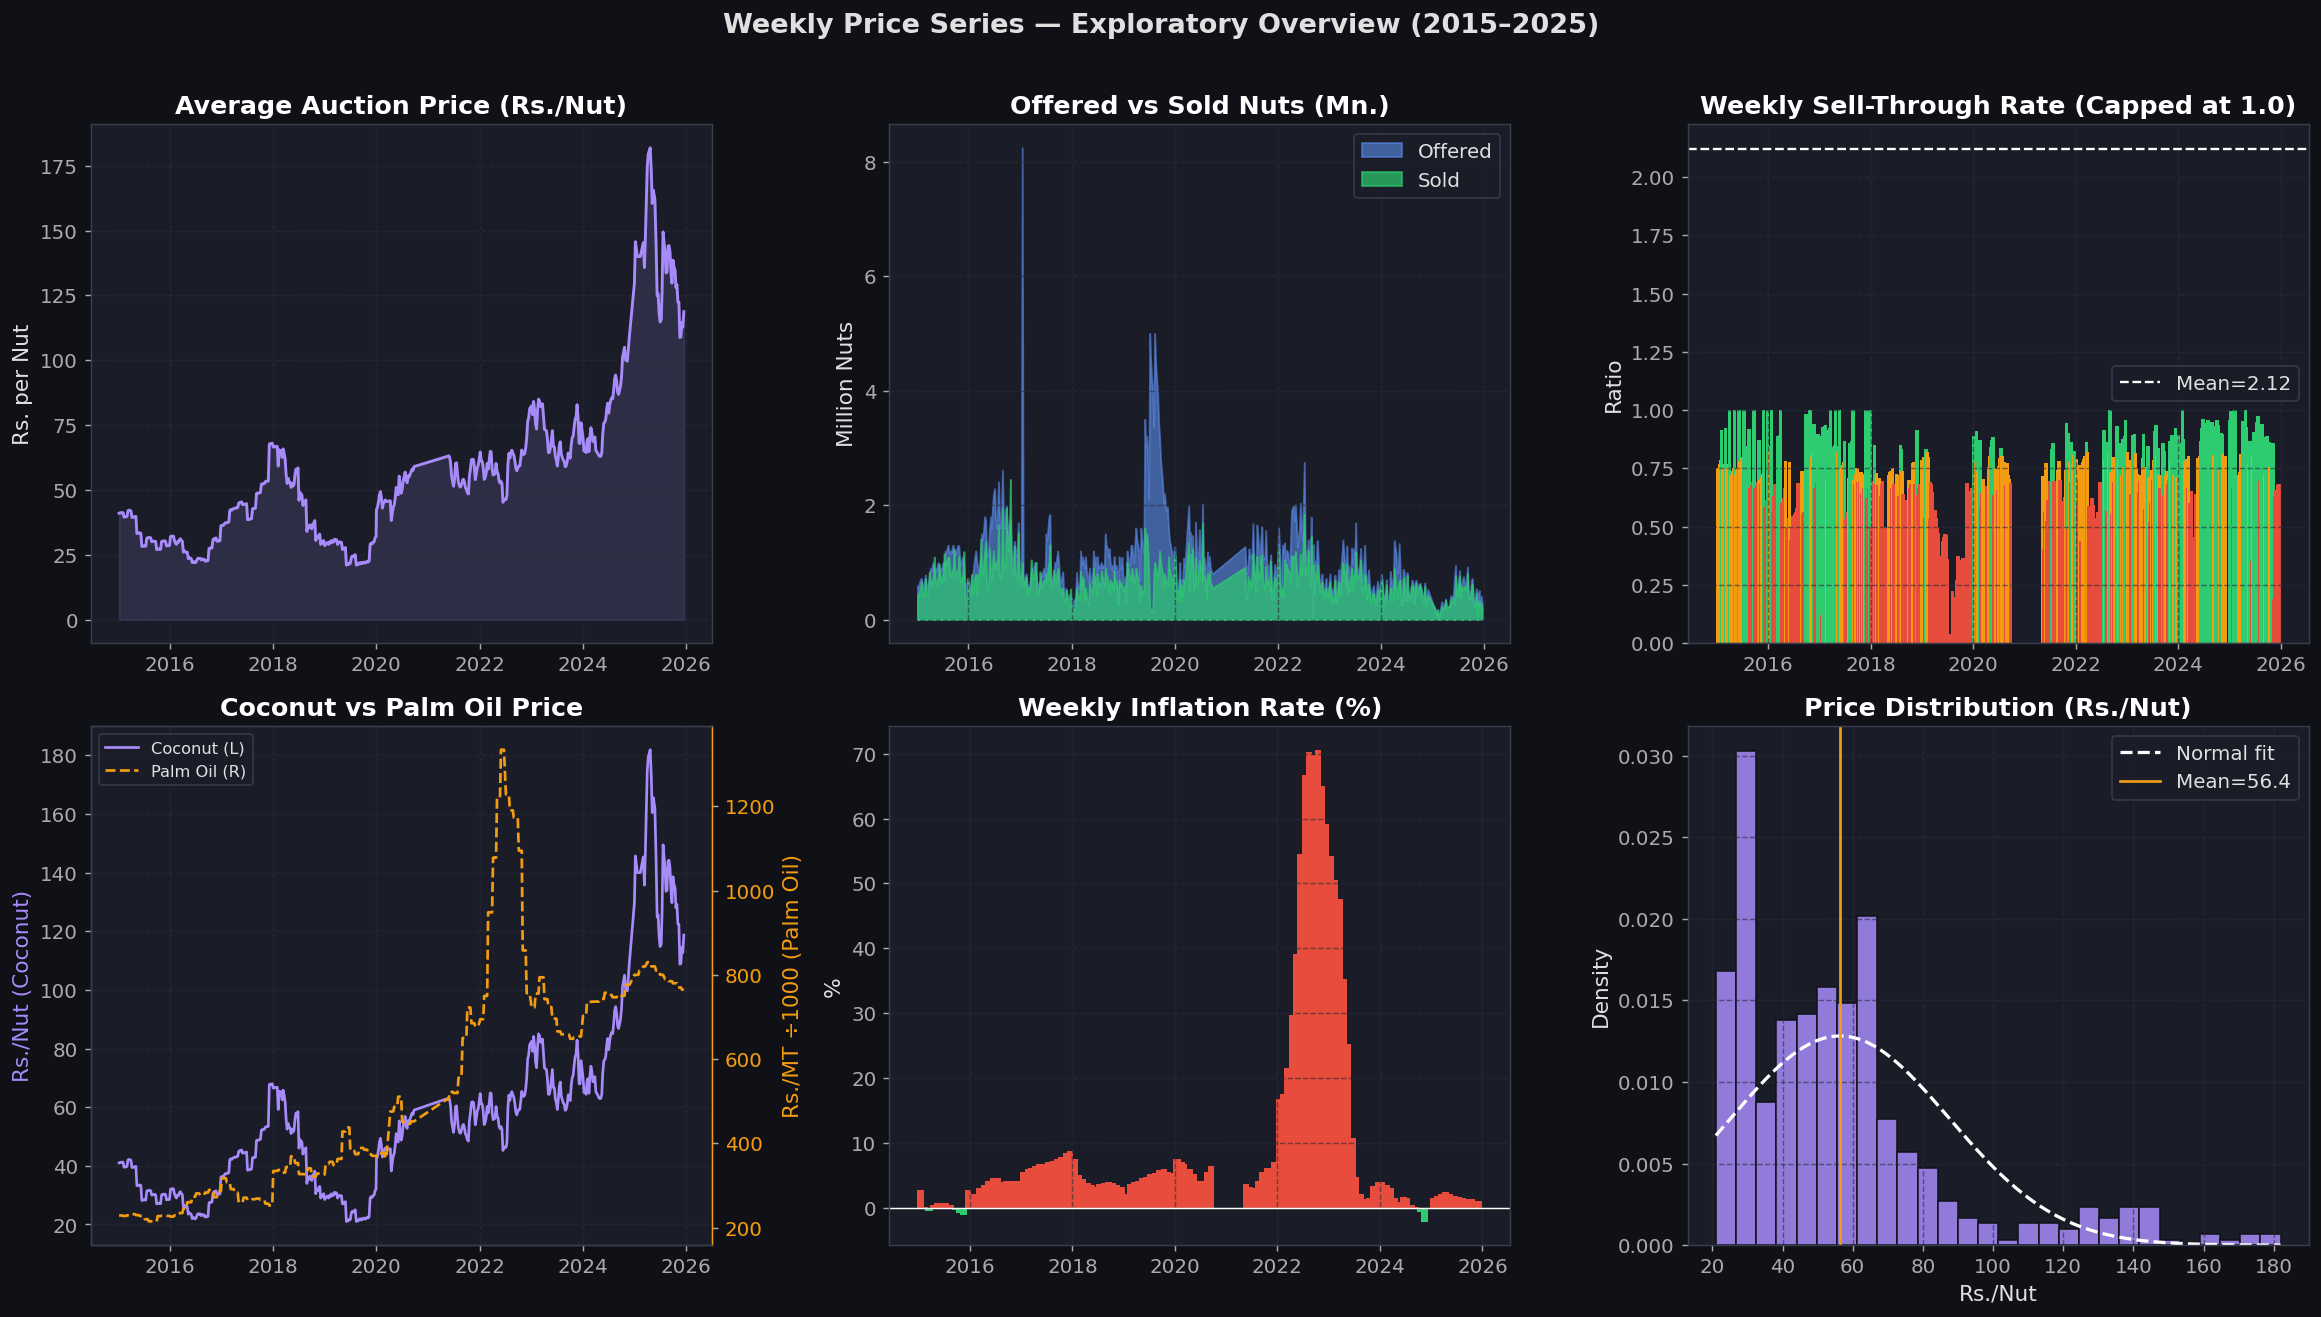

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Weekly Price Series — Exploratory Overview (2015–2025)', fontsize=15, fontweight='bold', y=1.01)

# 1. Price over time
ax = axes[0,0]
ax.plot(df_weekly['Date'], df_weekly['Avg_Price']/1000, color='#a78bfa', linewidth=1.6)
ax.fill_between(df_weekly['Date'], df_weekly['Avg_Price']/1000, alpha=0.15, color='#a78bfa')
ax.set_title('Average Auction Price (Rs./Nut)', fontweight='bold')
ax.set_ylabel('Rs. per Nut')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}'))
ax.grid(True)

# 2. Offered vs Sold Nuts
ax = axes[0,1]
ax.fill_between(df_weekly['Date'], df_weekly['Offered_Nuts']/1e6, label='Offered', alpha=0.6, color='#5b8dee')
ax.fill_between(df_weekly['Date'], df_weekly['Sold_Nuts']/1e6, label='Sold', alpha=0.7, color='#2ecc71')
ax.set_title('Offered vs Sold Nuts (Mn.)', fontweight='bold')
ax.set_ylabel('Million Nuts')
ax.legend()
ax.grid(True)

# 3. Sell-Through Rate
ax = axes[0,2]
# Cap sell-through rate at 1.0 for visualization to handle anomalous values
sell_through_rate_capped = df_weekly['Sell_Through_Rate'].clip(upper=1.0)
colors_str = ['#2ecc71' if v >= 0.82 else '#f39c12' if v >= 0.70 else '#e74c3c' for v in sell_through_rate_capped]
ax.bar(df_weekly['Date'], sell_through_rate_capped, color=colors_str, width=25)
ax.axhline(df_weekly['Sell_Through_Rate'].mean(), color='white', linewidth=1.3, linestyle='--', label=f'Mean={df_weekly["Sell_Through_Rate"].mean():.2f}')
ax.set_title('Weekly Sell-Through Rate (Capped at 1.0)', fontweight='bold')
ax.set_ylabel('Ratio')
ax.legend()
ax.grid(True)

# 4. Palm Oil Price vs Coconut Price
ax = axes[1,0]
ax2 = ax.twinx()
ax.plot(df_weekly['Date'], df_weekly['Avg_Price']/1000, color='#a78bfa', linewidth=1.5, label='Coconut (L)')
ax2.plot(df_weekly['Date'], df_weekly['Palm_Oil_Price']/1000, color='#f39c12', linewidth=1.5, linestyle='--', label='Palm Oil (R)')
ax.set_title('Coconut vs Palm Oil Price', fontweight='bold')
ax.set_ylabel('Rs./Nut (Coconut)', color='#a78bfa')
ax2.set_ylabel('Rs./MT ÷1000 (Palm Oil)', color='#f39c12')
ax2.tick_params(axis='y', labelcolor='#f39c12')
ax2.spines['right'].set_color('#f39c12')
lines1,labs1 = ax.get_legend_handles_labels()
lines2,labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, loc='upper left', fontsize=9)
ax.grid(True)

# 5. Inflation
ax = axes[1,1]
c = ['#e74c3c' if v > 0 else '#2ecc71' for v in df_weekly['Inflation']]
ax.bar(df_weekly['Date'], df_weekly['Inflation'], color=c, width=25)
ax.axhline(0, color='white', linewidth=0.8)
ax.set_title('Weekly Inflation Rate (%)', fontweight='bold')
ax.set_ylabel('%')
ax.grid(True)

# 6. Price distribution
ax = axes[1,2]
ax.hist(df_weekly['Avg_Price']/1000, bins=28, color='#a78bfa', edgecolor='#0f1117', alpha=0.85, density=True)
xrng = np.linspace(df_weekly['Avg_Price'].min()/1000, df_weekly['Avg_Price'].max()/1000, 200)
mu, sd = df_weekly['Avg_Price'].mean()/1000, df_weekly['Avg_Price'].std()/1000
ax.plot(xrng, stats.norm.pdf(xrng, mu, sd), color='white', linewidth=1.8, linestyle='--', label='Normal fit')
ax.axvline(mu, color='#f39c12', linewidth=1.5, label=f'Mean={mu:.1f}')
ax.set_title('Price Distribution (Rs./Nut)', fontweight='bold')
ax.set_xlabel('Rs./Nut')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

---
## 3. Market Regime Clustering — Gaussian Mixture Model (K = 3)
### Rationale: GMM is selected over K-Means because it models elliptical, non-spherical clusters and provides probabilistic regime memberships — critical for financial regime detection where price distributions are heteroskedastic.

In [34]:
# ── Feature engineering for clustering ────────────────────────
clust_df = df_weekly[['Date','Year','Month','Avg_Price','Sell_Through_Rate',
                        'Palm_Oil_Price','Inflation']].copy()
clust_df['Sell_Through_Rate'] = clust_df['Sell_Through_Rate'].clip(upper=1.0) # Cap STR for clustering
clust_df['Price_Rolling_3w']   = clust_df['Avg_Price'].rolling(3).mean()
clust_df['Price_Volatility_3w']= clust_df['Avg_Price'].rolling(3).std()
clust_df['Price_Momentum']     = clust_df['Avg_Price'].diff(3)

# Fill initial NaNs from rolling calculations to retain all rows
# Using bfill to propagate the first valid observation backward
clust_df['Price_Rolling_3w'] = clust_df['Price_Rolling_3w'].bfill()
clust_df['Price_Volatility_3w'] = clust_df['Price_Volatility_3w'].bfill()
clust_df['Price_Momentum'] = clust_df['Price_Momentum'].bfill()

# Ensure no other NaNs remain (e.g., if there were NaNs in original df_weekly)
clust_df = clust_df.dropna().reset_index(drop=True)

features = ['Avg_Price','Sell_Through_Rate','Price_Volatility_3w','Price_Momentum','Inflation']
X = clust_df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── GMM model selection (BIC / AIC sweep K=2..6) ──────────────────
bic_scores, aic_scores = [], []
for k in range(2, 7):
    gm = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=10)
    gm.fit(X_scaled)
    bic_scores.append(gm.bic(X_scaled))
    aic_scores.append(gm.aic(X_scaled))

print('GMM MODEL SELECTION (BIC / AIC)')
print('=' * 45)
sel_df = pd.DataFrame({'K': range(2,7), 'BIC': bic_scores, 'AIC': aic_scores})
sel_df['Delta_BIC'] = sel_df['BIC'] - sel_df['BIC'].min()
print(sel_df.round(1).to_string(index=False))

# ── Fit final GMM (K=3) ─────────────────────────
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42, n_init=20)
gmm.fit(X_scaled)
labels_raw = gmm.predict(X_scaled)
proba = gmm.predict_proba(X_scaled)
clust_df['Cluster_Raw'] = labels_raw

# ── Assign meaningful regime names by mean price rank ─────────
mean_price_by_cluster = clust_df.groupby('Cluster_Raw')['Avg_Price'].mean().sort_values()
rank_map = {mean_price_by_cluster.index[0]: 'Stable',
            mean_price_by_cluster.index[1]: 'Warning',
            mean_price_by_cluster.index[2]: 'Crisis'}
clust_df['Regime'] = clust_df['Cluster_Raw'].map(rank_map)

# ── Cluster quality metrics ────────────────────────────
sil  = silhouette_score(X_scaled, labels_raw)
ch   = calinski_harabasz_score(X_scaled, labels_raw)
db   = davies_bouldin_score(X_scaled, labels_raw)

print(f'\nCLUSTER VALIDATION METRICS (K=3)')
print('=' * 45)
print(f'  Silhouette Score       : {sil:.4f}  (higher is better, max=1)')
print(f'  Calinski-Harabasz      : {ch:.2f}  (higher is better)')
print(f'  Davies-Bouldin         : {db:.4f}  (lower is better)')

# ── Regime summary table ─────────────────────────
reg_summary = clust_df.groupby('Regime').agg(
    Count=('Avg_Price','count'),
    Mean_Price=('Avg_Price','mean'),
    Std_Price=('Avg_Price','std'),
    Min_Price=('Avg_Price','min'),
    Max_Price=('Avg_Price','max'),
    Mean_STR=('Sell_Through_Rate','mean'),
    Mean_Inflation=('Inflation','mean'),
    Mean_Volatility=('Price_Volatility_3w','mean'),
).round(2)
reg_summary['Share_%'] = (reg_summary['Count'] / reg_summary['Count'].sum() * 100).round(1)
print(f'\nREGIME SUMMARY TABLE')
print('=' * 100)
print(reg_summary.to_string())

GMM MODEL SELECTION (BIC / AIC)
 K    BIC    AIC  Delta_BIC
 2 5240.8 5066.7      948.3
 3 4788.3 4524.9      495.7
 4 4334.4 3981.8       41.8
 5 4292.6 3850.8        0.0
 6 4321.7 3790.7       29.1

CLUSTER VALIDATION METRICS (K=3)
  Silhouette Score       : 0.1670  (higher is better, max=1)
  Calinski-Harabasz      : 94.05  (higher is better)
  Davies-Bouldin         : 1.8136  (lower is better)

REGIME SUMMARY TABLE
         Count  Mean_Price  Std_Price  Min_Price  Max_Price  Mean_STR  Mean_Inflation  Mean_Volatility  Share_%
Regime                                                                                                         
Crisis      85    73212.99   26635.02   45241.65  179497.23      0.73           39.18          3771.02     16.4
Stable     228    36953.97   12124.17   21000.00   68000.00      0.66            4.07           553.48     44.1
Warning    204    71068.73   35288.91   21000.00  181915.68      0.76            3.28          3181.61     39.5


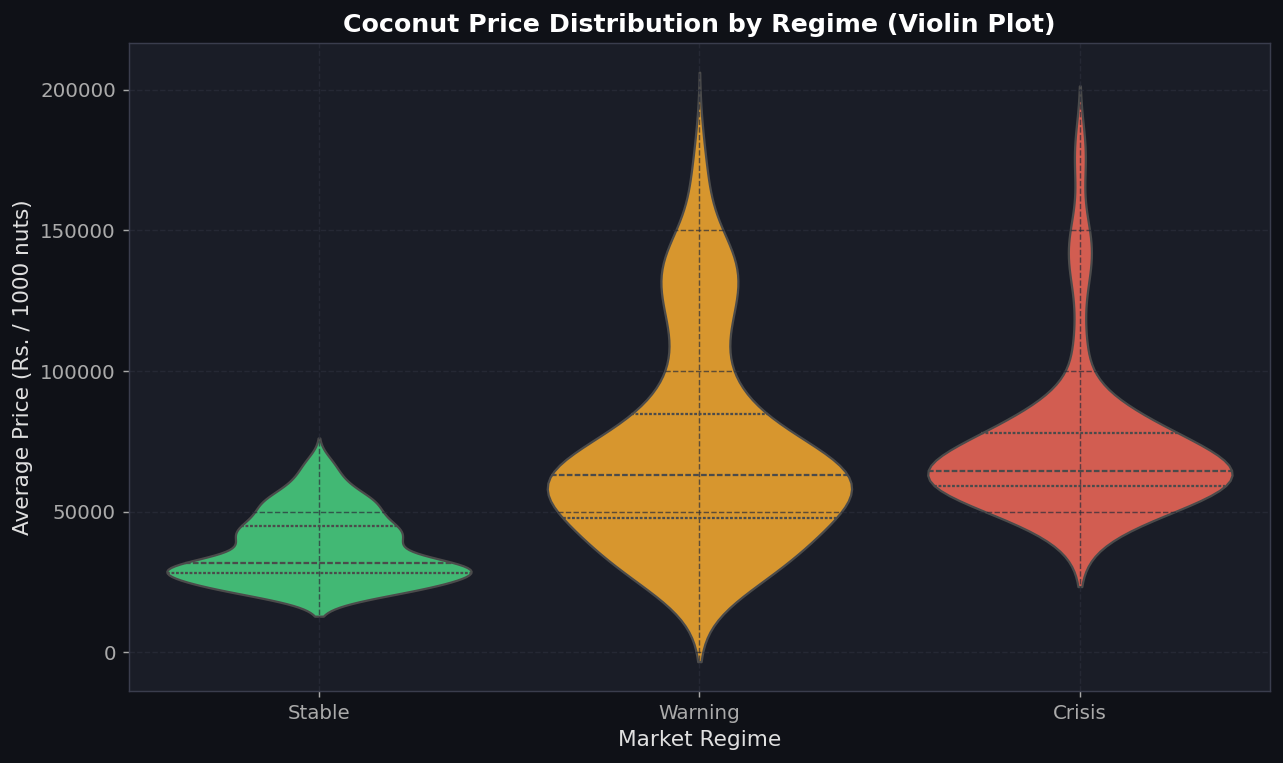

In [33]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Regime', y='Avg_Price', data=clust_df, order=regime_order, palette=PALETTE, inner='quartile')
plt.title('Coconut Price Distribution by Regime (Violin Plot)', fontweight='bold')
plt.xlabel('Market Regime')
plt.ylabel('Average Price (Rs. / 1000 nuts)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

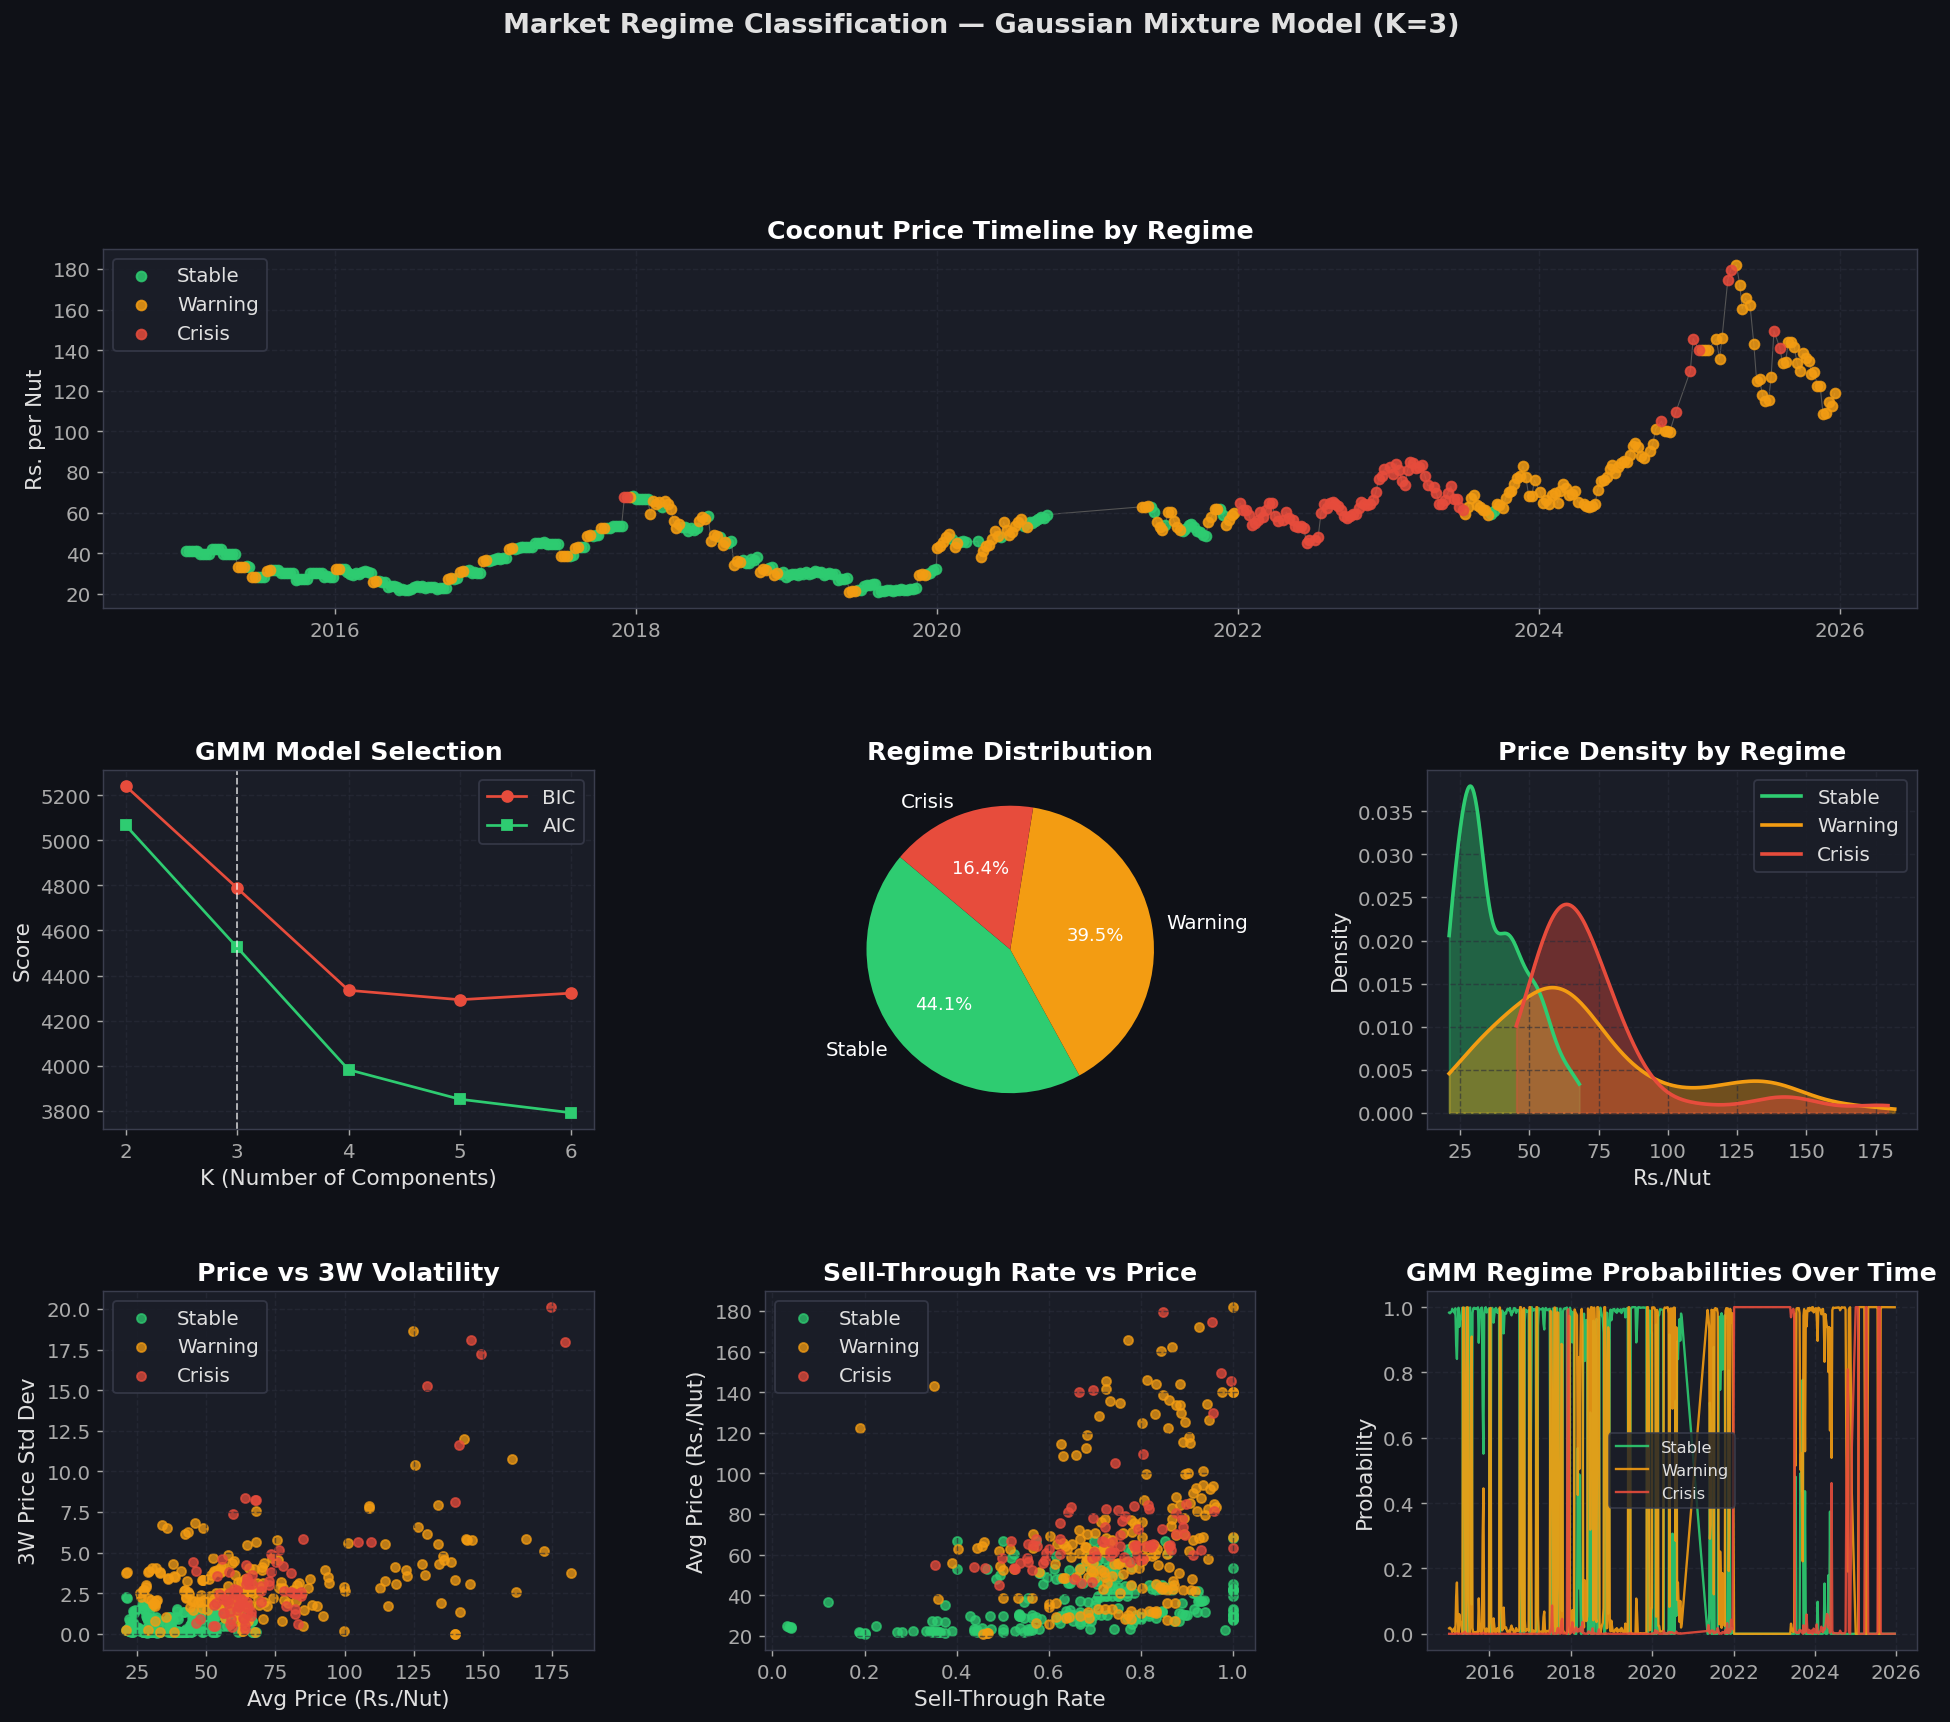

In [31]:
fig = plt.figure(figsize=(18, 14))
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Market Regime Classification — Gaussian Mixture Model (K=3)', fontsize=15, fontweight='bold', y=1.01)

regime_order = ['Stable','Warning','Crisis']

# 1. Price timeline colored by regime
ax1 = fig.add_subplot(gs[0, :])
for regime in regime_order:
    mask = clust_df['Regime'] == regime
    ax1.scatter(clust_df.loc[mask,'Date'], clust_df.loc[mask,'Avg_Price']/1000,
                color=PALETTE[regime], s=30, label=regime, zorder=3, alpha=0.85)
ax1.plot(clust_df['Date'], clust_df['Avg_Price']/1000, color='#555', linewidth=0.6, zorder=1)
ax1.set_title('Coconut Price Timeline by Regime', fontweight='bold')
ax1.set_ylabel('Rs. per Nut')
ax1.legend(loc='upper left')
ax1.grid(True)

# 2. BIC/AIC model selection
ax2 = fig.add_subplot(gs[1, 0])
ks = list(range(2,7))
ax2.plot(ks, bic_scores, color='#e74c3c', marker='o', label='BIC')
ax2.plot(ks, aic_scores, color='#2ecc71', marker='s', label='AIC')
ax2.axvline(3, color='white', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_title('GMM Model Selection', fontweight='bold')
ax2.set_xlabel('K (Number of Components)')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(True)

# 3. Regime distribution pie
ax3 = fig.add_subplot(gs[1, 1])
counts = [reg_summary.loc[r,'Count'] for r in regime_order]
wedge_colors = [PALETTE[r] for r in regime_order]
wedges, texts, autotexts = ax3.pie(counts, labels=regime_order, colors=wedge_colors,
                                    autopct='%1.1f%%', startangle=140,
                                    textprops={'color':'white','fontsize':11})
for at in autotexts: at.set_fontsize(10)
ax3.set_title('Regime Distribution', fontweight='bold')

# 4. Price density by regime
ax4 = fig.add_subplot(gs[1, 2])
for regime in regime_order:
    vals = clust_df.loc[clust_df['Regime']==regime,'Avg_Price']/1000
    xr = np.linspace(vals.min(), vals.max(), 200)
    kde = stats.gaussian_kde(vals)
    ax4.fill_between(xr, kde(xr), alpha=0.4, color=PALETTE[regime])
    ax4.plot(xr, kde(xr), color=PALETTE[regime], linewidth=2, label=regime)
ax4.set_title('Price Density by Regime', fontweight='bold')
ax4.set_xlabel('Rs./Nut')
ax4.set_ylabel('Density')
ax4.legend()
ax4.grid(True)

# 5. Scatter: Price vs Volatility
ax5 = fig.add_subplot(gs[2, 0])
for regime in regime_order:
    mask = clust_df['Regime'] == regime
    ax5.scatter(clust_df.loc[mask,'Avg_Price']/1000,
                clust_df.loc[mask,'Price_Volatility_3w']/1000,
                color=PALETTE[regime], s=25, alpha=0.75, label=regime)
ax5.set_title('Price vs 3W Volatility', fontweight='bold')
ax5.set_xlabel('Avg Price (Rs./Nut)')
ax5.set_ylabel('3W Price Std Dev')
ax5.legend()
ax5.grid(True)

# 6. Scatter: STR vs Price
ax6 = fig.add_subplot(gs[2, 1])
for regime in regime_order:
    mask = clust_df['Regime'] == regime
    ax6.scatter(clust_df.loc[mask,'Sell_Through_Rate'],
                clust_df.loc[mask,'Avg_Price']/1000,
                color=PALETTE[regime], s=25, alpha=0.75, label=regime)
ax6.set_title('Sell-Through Rate vs Price', fontweight='bold')
ax6.set_xlabel('Sell-Through Rate')
ax6.set_ylabel('Avg Price (Rs./Nut)')
ax6.legend()
ax6.grid(True)

# 7. Regime probability heatmap over time
ax7 = fig.add_subplot(gs[2, 2])
# Re-order probabilities to Stable/Warning/Crisis
stable_col  = list(rank_map.keys())[list(rank_map.values()).index('Stable')]
warning_col = list(rank_map.keys())[list(rank_map.values()).index('Warning')]
crisis_col  = list(rank_map.keys())[list(rank_map.values()).index('Crisis')]
prob_matrix = np.column_stack([
    proba[:,stable_col],
    proba[:,warning_col],
    proba[:,crisis_col]
])
for i,(regime,col) in enumerate(zip(regime_order,[PALETTE[r] for r in regime_order])):
    ax7.plot(clust_df['Date'], prob_matrix[:,i], color=col, linewidth=1.3, label=regime, alpha=0.9)
ax7.set_title('GMM Regime Probabilities Over Time', fontweight='bold')
ax7.set_ylabel('Probability')
ax7.legend(fontsize=9)
ax7.grid(True)

plt.show()

---
## 4. Price Elasticity of Demand — By Regime

In [8]:
# ── Merge regime labels into monthly data ─────────────────────────────
# Create a 'Date' column in df_weekly from 'Year' and 'Month'
df_weekly['Date'] = pd.to_datetime(df_weekly['Year'].astype(str) + '-' + df_weekly['Month'], format='%Y-%b')

# Create a month-start date for clust_df to align with df_weekly
clust_df['Month_Date'] = clust_df['Date'].dt.to_period('M').dt.start_time

# Aggregate weekly regimes to get a monthly regime (e.g., by mode)
# If a month has multiple weekly regimes, take the most frequent one
monthly_regimes = clust_df.groupby('Month_Date')['Regime'].agg(lambda x: x.mode()[0]).reset_index()
monthly_regimes = monthly_regimes.rename(columns={'Month_Date': 'Date', 'Regime': 'Monthly_Regime'})

df_elas_merged = df_weekly.merge(
    monthly_regimes[['Date', 'Monthly_Regime']],
    on='Date',
    how='left'
).dropna(subset=['Monthly_Regime'])

df_elas_merged['Log_Price'] = np.log(df_elas_merged['Avg_Price'])
df_elas_merged['Log_Demand'] = np.log(df_elas_merged['Sold_Nuts'])

# ── OLS log-log regression per regime (arc elasticity approach) ──────────────────
elast_results = []
for regime in ['Stable','Warning','Crisis']:
    # Use 'Monthly_Regime' for filtering
    sub = df_elas_merged[df_elas_merged['Monthly_Regime']==regime].dropna(subset=['Log_Price','Log_Demand'])
    if len(sub) < 5:
        # For debugging, print which regime was skipped and why
        print(f"Skipping {regime} regime due to insufficient observations ({len(sub)} < 5).")
        continue
    # Log-log OLS: coefficient = price elasticity
    X_ols = sm.add_constant(sub['Log_Price'])
    model = sm.OLS(sub['Log_Demand'], X_ols).fit(cov_type='HC3')
    coef   = model.params['Log_Price']
    pval   = model.pvalues['Log_Price']
    ci_lo  = model.conf_int().loc['Log_Price',0]
    ci_hi  = model.conf_int().loc['Log_Price',1]
    r2     = model.rsquared

    # Mid-point elasticity (arc method) as cross-check
    dp = sub['Log_Price'].diff().dropna()
    dq = sub['Log_Demand'].diff().dropna()
    arc_e = (dq / dp).replace([np.inf,-np.inf], np.nan).dropna().median()

    elast_results.append({
        'Regime': regime,
        'N_Obs': len(sub),
        'OLS_Elasticity': round(coef,4),
        'CI_Lower': round(ci_lo,4),
        'CI_Upper': round(ci_hi,4),
        'P_Value': round(pval,4),
        'R_Squared': round(r2,4),
        'Arc_Elasticity': round(arc_e,4),
        'Elasticity_Type': 'Inelastic' if abs(coef) < 1 else 'Elastic',
        'Interpretation': 'Inelastic — demand relatively insensitive to price' if abs(coef)<1
                          else 'Elastic — demand highly sensitive to price'
    })

elas_df = pd.DataFrame(elast_results)
print('PRICE ELASTICITY OF DEMAND BY REGIME — LOG-LOG OLS (HC3 Robust SE)')
print('=' * 110)
print(elas_df.to_string(index=False))

PRICE ELASTICITY OF DEMAND BY REGIME — LOG-LOG OLS (HC3 Robust SE)
 Regime  N_Obs  OLS_Elasticity  CI_Lower  CI_Upper  P_Value  R_Squared  Arc_Elasticity Elasticity_Type                                     Interpretation
 Stable    256         -0.4573   -0.6548   -0.2598      0.0     0.1149         -4.4899       Inelastic Inelastic — demand relatively insensitive to price
Warning    176         -0.8059   -0.9805   -0.6314      0.0     0.3915         -2.7645       Inelastic Inelastic — demand relatively insensitive to price
 Crisis     85         -1.3733   -1.7782   -0.9684      0.0     0.5006         -2.4908         Elastic         Elastic — demand highly sensitive to price


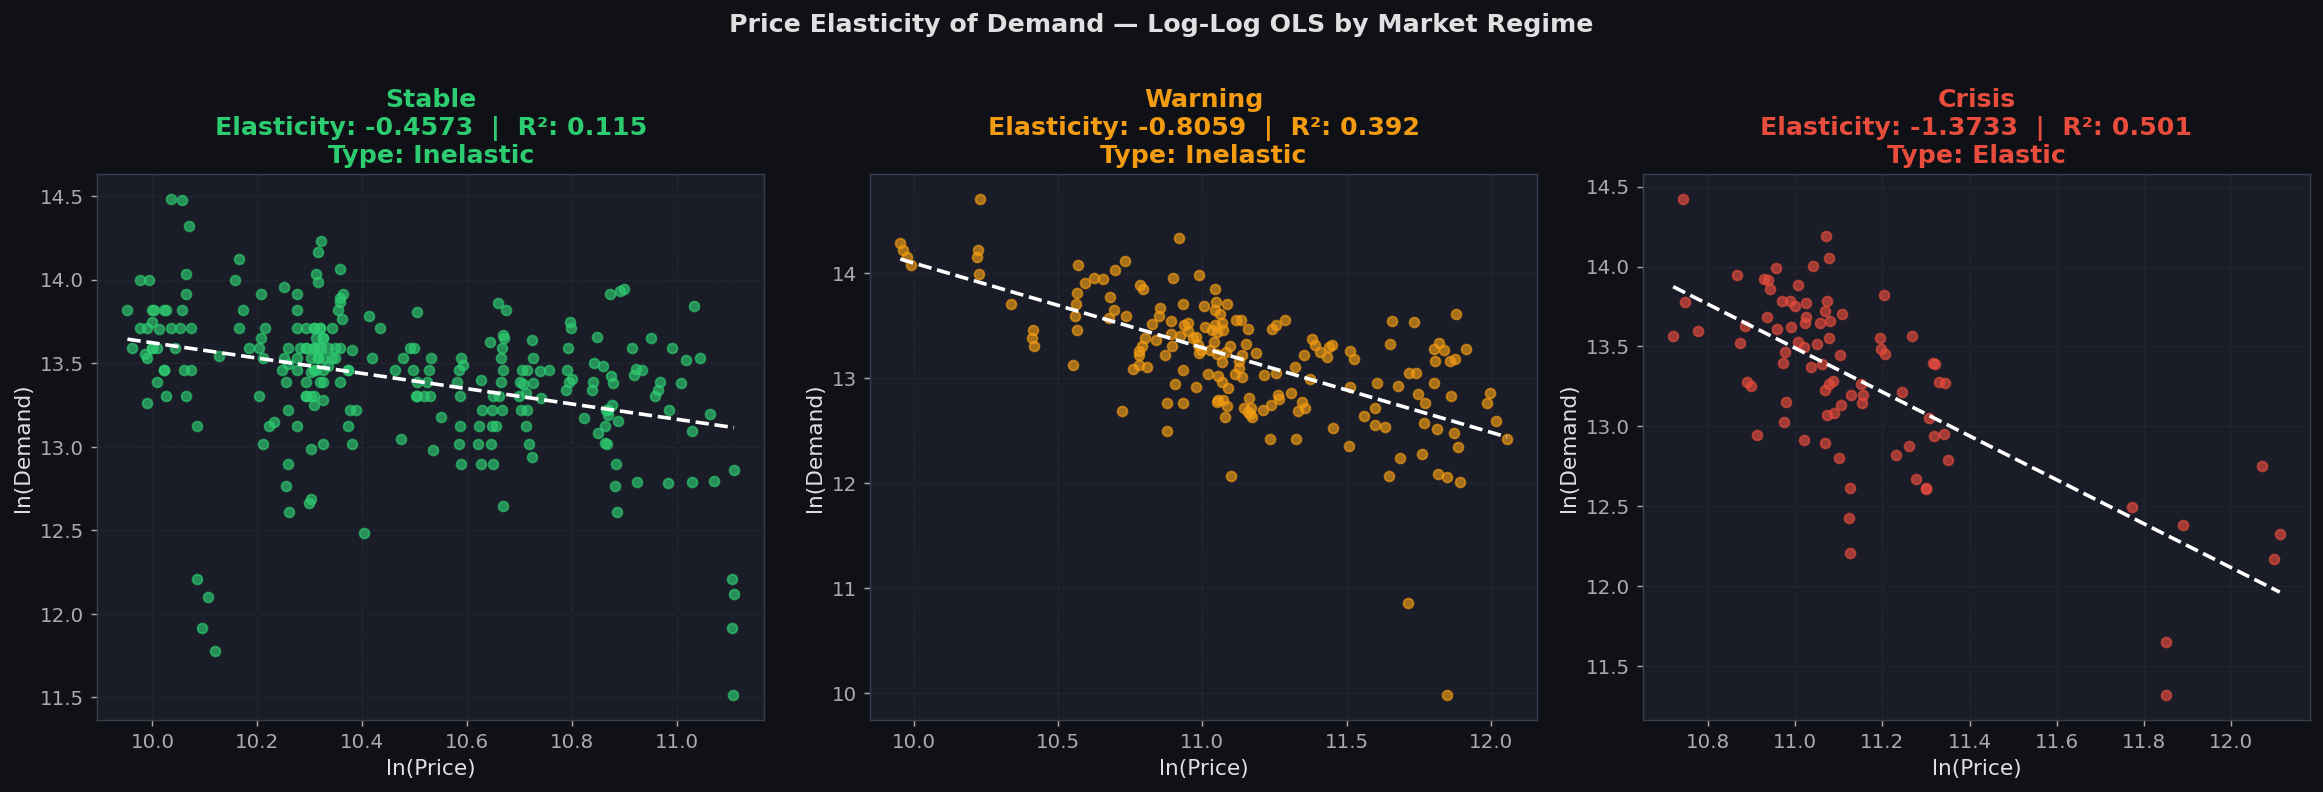

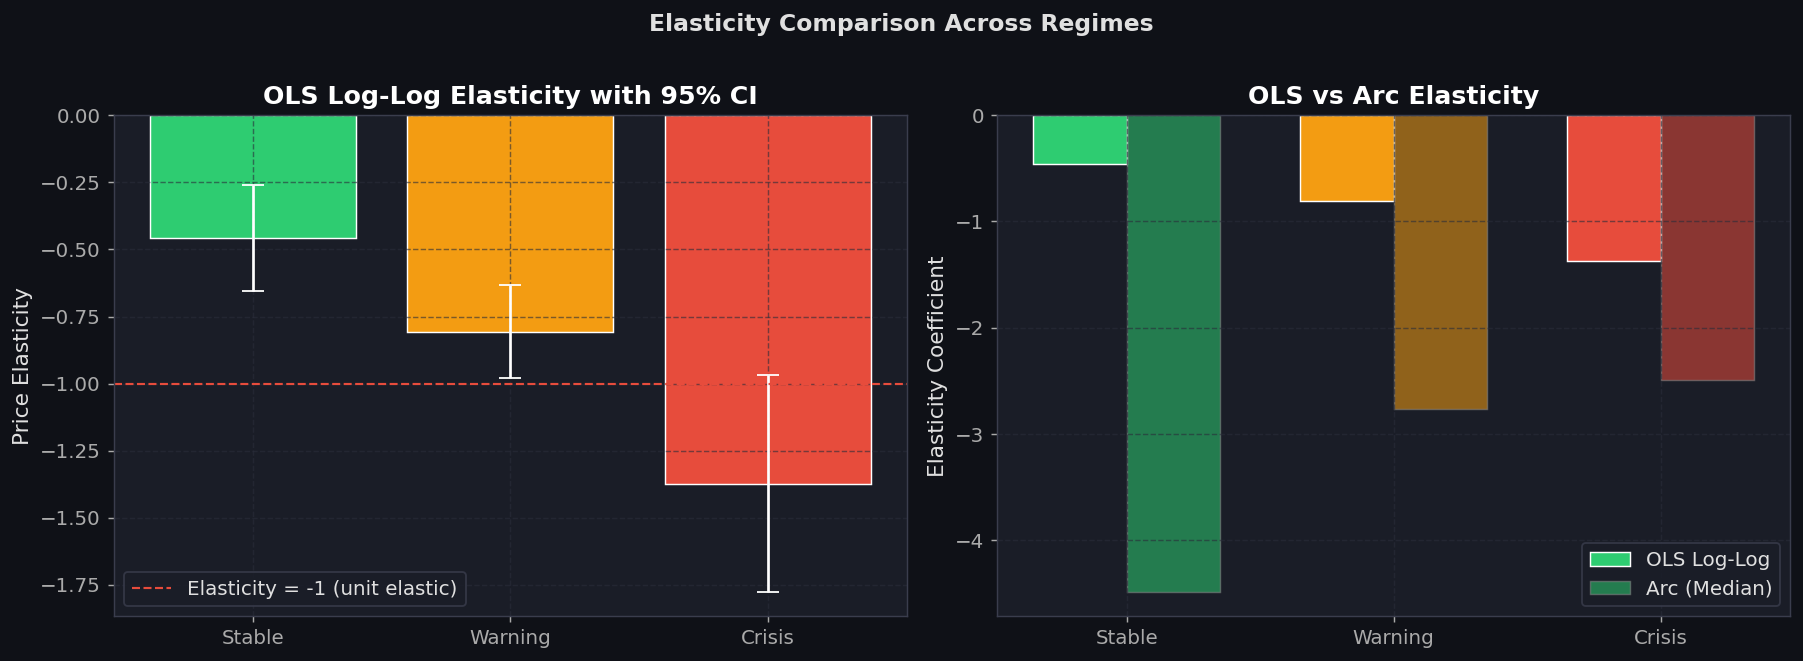

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Price Elasticity of Demand — Log-Log OLS by Market Regime', fontsize=14, fontweight='bold', y=1.01)

for ax, row in zip(axes, elast_results):
    regime = row['Regime']
    sub = df_elas_merged[df_elas_merged['Monthly_Regime']==regime].dropna(subset=['Log_Price','Log_Demand'])

    # Scatter
    ax.scatter(sub['Log_Price'], sub['Log_Demand'], color=PALETTE[regime], alpha=0.65, s=30, zorder=3)

    # OLS line
    x_line = np.linspace(sub['Log_Price'].min(), sub['Log_Price'].max(), 100)
    X_fit = sm.add_constant(x_line)
    X_ols = sm.add_constant(sub['Log_Price'])
    mdl   = sm.OLS(sub['Log_Demand'], X_ols).fit()
    y_fit = mdl.params['const'] + mdl.params['Log_Price'] * x_line
    ax.plot(x_line, y_fit, color='white', linewidth=2, linestyle='--', zorder=4)

    elast = row['OLS_Elasticity']
    ax.set_title(f'{regime}\n'
                 f'Elasticity: {elast:.4f}  |  R²: {row["R_Squared"]:.3f}\n'
                 f'Type: {row["Elasticity_Type"]}',
                 fontweight='bold', color=PALETTE[regime])
    ax.set_xlabel('ln(Price)')
    ax.set_ylabel('ln(Demand)')
    ax.grid(True)

plt.tight_layout()
plt.show()

# Comparative bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Elasticity Comparison Across Regimes', fontsize=13, fontweight='bold', y=1.01)

regimes = [r['Regime'] for r in elast_results]
ols_e   = [r['OLS_Elasticity'] for r in elast_results]
arc_e   = [r['Arc_Elasticity'] for r in elast_results]
colors  = [PALETTE[r] for r in regimes]
ci_lo   = [r['CI_Lower'] for r in elast_results]
ci_hi   = [r['CI_Upper'] for r in elast_results]
yerr_lo = [abs(e - lo) for e,lo in zip(ols_e,ci_lo)]
yerr_hi = [abs(hi - e) for e,hi in zip(ols_e,ci_hi)]

axes[0].bar(regimes, ols_e, color=colors, edgecolor='white', linewidth=0.8)
axes[0].errorbar(regimes, ols_e, yerr=[yerr_lo,yerr_hi], fmt='none', color='white', capsize=6, linewidth=1.5)
axes[0].axhline(-1, color='#e74c3c', linewidth=1.2, linestyle='--', label='Elasticity = -1 (unit elastic)')
axes[0].set_title('OLS Log-Log Elasticity with 95% CI', fontweight='bold')
axes[0].set_ylabel('Price Elasticity')
axes[0].legend()
axes[0].grid(True)

x = np.arange(len(regimes))
w = 0.35
axes[1].bar(x-w/2, ols_e, width=w, color=colors, edgecolor='white', linewidth=0.8, label='OLS Log-Log')
axes[1].bar(x+w/2, arc_e, width=w, color=colors, edgecolor='#888', linewidth=0.8, alpha=0.55, label='Arc (Median)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(regimes)
axes[1].set_title('OLS vs Arc Elasticity', fontweight='bold')
axes[1].set_ylabel('Elasticity Coefficient')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Step 1: Calculate annual demand change from the 'annual' DataFrame
annual['Demand_Change_%'] = annual['Sold_Nuts'].pct_change().mul(100).round(1)

# Step 2: Determine the dominant regime for each year from clust_df
# clust_df already contains 'Year' and 'Regime' from weekly data.
dominant_regime_per_year = clust_df.groupby('Year')['Regime'].agg(lambda x: x.mode()[0]).reset_index()
dominant_regime_per_year = dominant_regime_per_year.rename(columns={'Regime': 'Dominant_Regime'})

# Step 3: Merge annual data with dominant regime per year
df_merged_annual_regime = annual.reset_index().merge(dominant_regime_per_year, on='Year', how='left')

# Step 4: Prepare elasticity data for merging
elas_for_merge = elas_df[['Regime', 'OLS_Elasticity', 'Elasticity_Type', 'Interpretation']].copy()
elas_for_merge['Sensitivity_Level_%'] = (elas_for_merge['OLS_Elasticity'].abs() * 100).round(2)
elas_for_merge = elas_for_merge.rename(columns={'Regime': 'Dominant_Regime'})

# Step 5: Merge the combined annual and regime data with elasticity data
df_final_table = df_merged_annual_regime.merge(elas_for_merge, on='Dominant_Regime', how='left')

# Step 6: Select and rename columns as requested by the user
output_table = df_final_table[[
    'Year',
    'Dominant_Regime',
    'Avg_Price', # This is Avg_Price from annual, which is per 1000 nuts
    'YoY_Price_Change_%',
    'Demand_Change_%',
    'OLS_Elasticity',
    'Sensitivity_Level_%',
    'Interpretation'
]].copy()

output_table.columns = [
    'Year',
    'Regime',
    'Avg Annual Price (Rs./1000 nuts)',
    'Price Change (%)',
    'Demand Change(%)',
    'Elasticity Coefficient',
    'Sensitivity Level (%)',
    'Interpretation'
]

# Step 7: Convert 'Avg Annual Price (Rs./1000 nuts)' to 'Avg Annual Price (Rs./Nut)'
output_table['Avg Annual Price (Rs./Nut)'] = (output_table['Avg Annual Price (Rs./1000 nuts)'] / 1000).round(2)
output_table = output_table.drop(columns=['Avg Annual Price (Rs./1000 nuts)'])

# Step 8: Reorder columns to match user's request precisely
output_table = output_table[[
    'Year',
    'Regime',
    'Avg Annual Price (Rs./Nut)',
    'Price Change (%)',
    'Demand Change(%)',
    'Elasticity Coefficient',
    'Sensitivity Level (%)',
    'Interpretation'
]].round(2)

print('YEARLY MARKET DYNAMICS & REGIME ELASTICITY SUMMARY')
print('=' * 120)
print(output_table.to_string(index=False))

YEARLY MARKET DYNAMICS & REGIME ELASTICITY SUMMARY
 Year  Regime  Avg Annual Price (Rs./Nut)  Price Change (%)  Demand Change(%)  Elasticity Coefficient  Sensitivity Level (%)                                     Interpretation
 2015  Stable                       33.62               NaN               NaN                   -0.46                  45.73 Inelastic — demand relatively insensitive to price
 2016  Stable                       27.04             -19.6              33.0                   -0.46                  45.73 Inelastic — demand relatively insensitive to price
 2017  Stable                       45.90              69.7             -33.7                   -0.46                  45.73 Inelastic — demand relatively insensitive to price
 2018  Stable                       48.12               4.9             -11.2                   -0.46                  45.73 Inelastic — demand relatively insensitive to price
 2019  Stable                       26.22             -45.5          

---
## 5. Time Series Diagnostics

/tmp/ipykernel_1871/47475625.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_diff_wk = kpss(diff_series, regression='c', nlags='auto')


STATIONARITY DIAGNOSTICS — WEEKLY DATA

LEVEL SERIES
ADF Statistic   : -2.8094  |  p-value: 0.0569
KPSS Statistic  : 0.1344  |  p-value: 0.0714
ADF Conclusion  : Non-stationary
KPSS Conclusion : Stationary

FIRST DIFFERENCE
ADF Statistic   : -7.3234  |  p-value: 0.0000
KPSS Statistic  : 0.0670  |  p-value: 0.1000
ADF Conclusion  : Stationary — d=1 sufficient
KPSS Conclusion : Stationary — d=1 confirmed


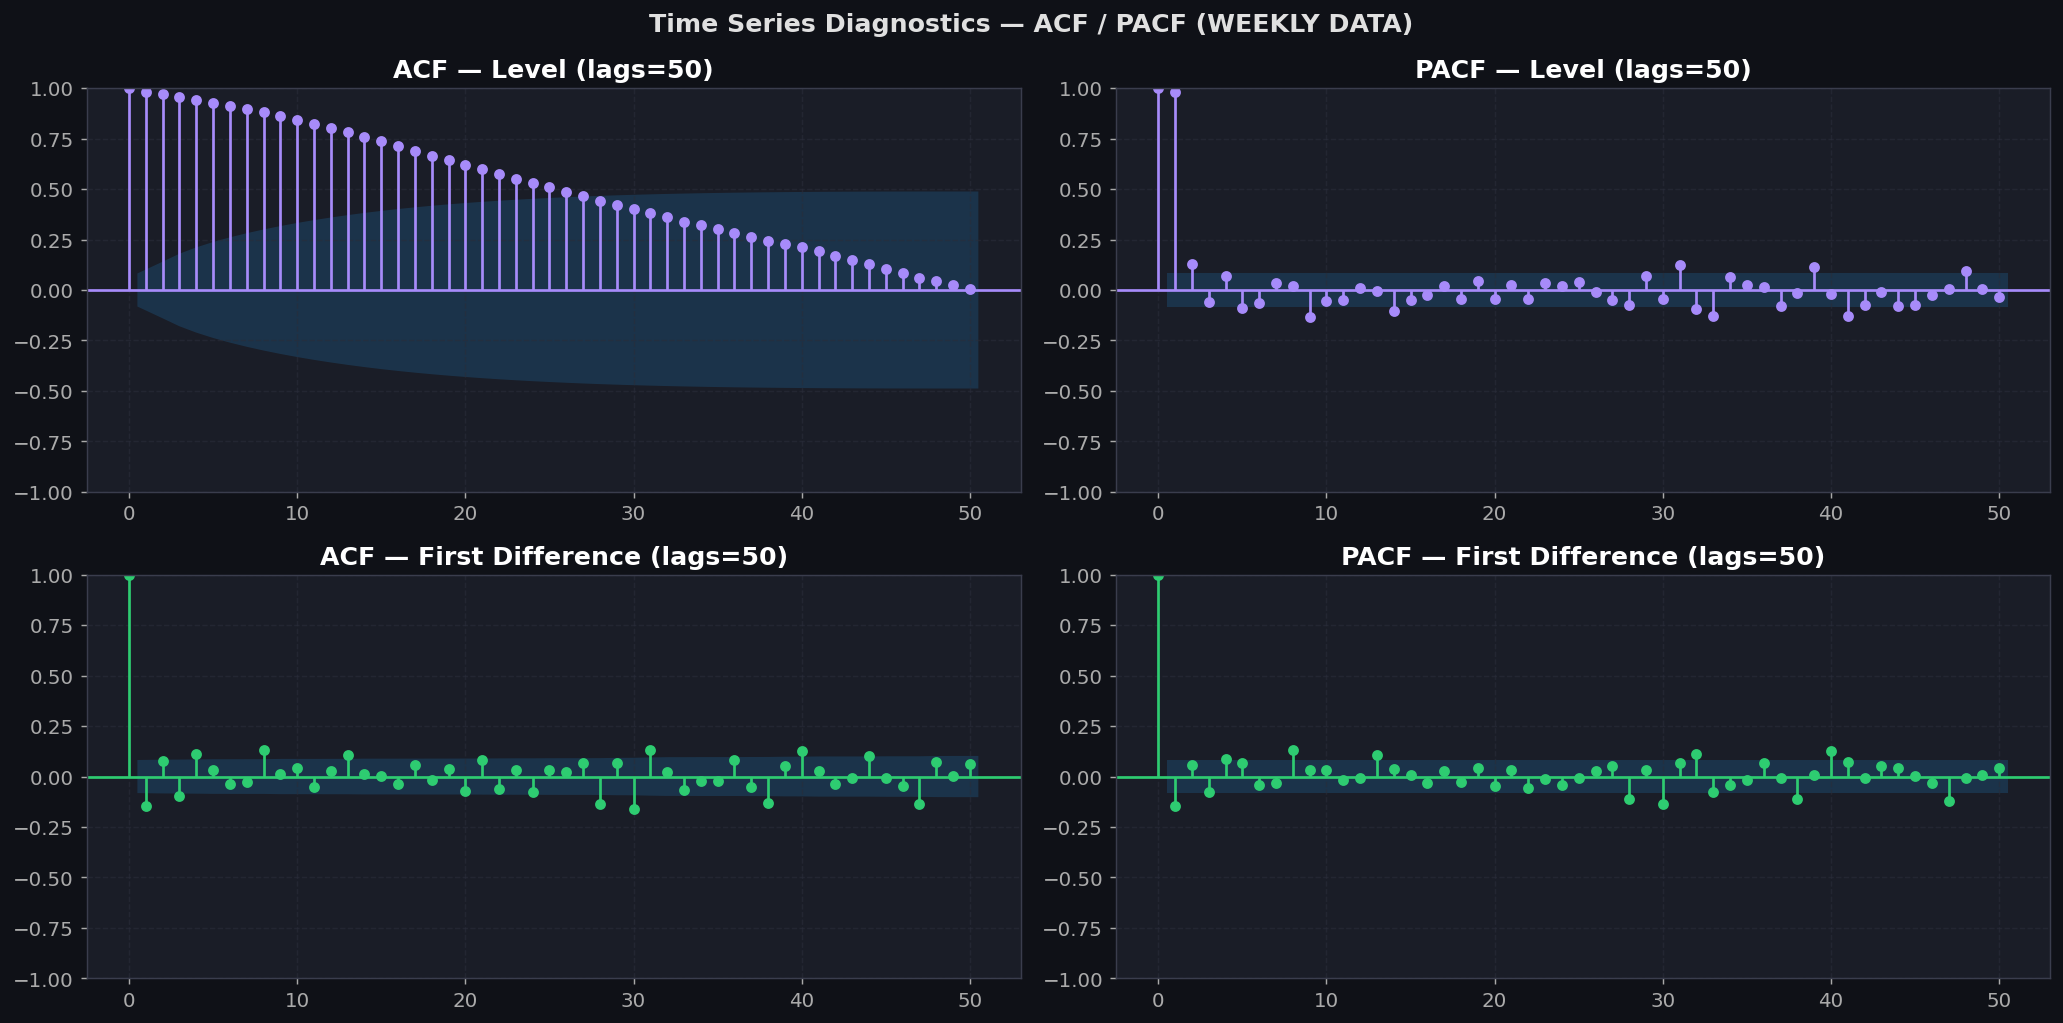

In [19]:
# ── Build weekly price series ──────────────────────────────────────────────
price_series_weekly = (
    df_weekly
    .copy()
    .assign(Date=pd.to_datetime(df_weekly['Week_Date'], errors='coerce'))
    .dropna(subset=['Date'])
    .sort_values('Date')
    .drop_duplicates(subset='Date')
    .set_index('Date')['Avg_Price']
    # Removed .asfreq('W-MON') and .dropna() to preserve all original weekly data points
)
# ── Stationarity tests (Weekly) ────────────────────────────────────────────
adf_res_wk  = adfuller(price_series_weekly, autolag='AIC')
kpss_res_wk = kpss(price_series_weekly, regression='ct', nlags='auto')

diff_series = price_series_weekly.diff().dropna()

adf_diff_wk  = adfuller(diff_series, autolag='AIC')
kpss_diff_wk = kpss(diff_series, regression='c', nlags='auto')

print('STATIONARITY DIAGNOSTICS — WEEKLY DATA')
print('=' * 70)

print('\nLEVEL SERIES')
print(f'ADF Statistic   : {adf_res_wk[0]:.4f}  |  p-value: {adf_res_wk[1]:.4f}')
print(f'KPSS Statistic  : {kpss_res_wk[0]:.4f}  |  p-value: {kpss_res_wk[1]:.4f}')
print(f'ADF Conclusion  : {"Non-stationary" if adf_res_wk[1] > 0.05 else "Stationary"}')
print(f'KPSS Conclusion : {"Non-stationary" if kpss_res_wk[1] < 0.05 else "Stationary"}')

print('\nFIRST DIFFERENCE')
print(f'ADF Statistic   : {adf_diff_wk[0]:.4f}  |  p-value: {adf_diff_wk[1]:.4f}')
print(f'KPSS Statistic  : {kpss_diff_wk[0]:.4f}  |  p-value: {kpss_diff_wk[1]:.4f}')
print(f'ADF Conclusion  : {"Non-stationary" if adf_diff_wk[1] > 0.05 else "Stationary — d=1 sufficient"}')
print(f'KPSS Conclusion : {"Non-stationary" if kpss_diff_wk[1] < 0.05 else "Stationary — d=1 confirmed"}')


# ── SAFE LAG CALCULATION (FIXES YOUR ERROR) ────────────────────────────────
def get_safe_lags(series, max_lag=50):
    n = len(series)
    return min(max_lag, max(5, n // 2))  # ensures stability


lags_level = get_safe_lags(price_series_weekly)
lags_diff  = get_safe_lags(diff_series)


# ── ACF / PACF plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Time Series Diagnostics — ACF / PACF (WEEKLY DATA)', fontsize=14, fontweight='bold')

# LEVEL
plot_acf(
    price_series_weekly,
    lags=lags_level,
    ax=axes[0,0],
    color='#a78bfa',
    vlines_kwargs={'colors':'#a78bfa'}
)
axes[0,0].set_title(f'ACF — Level (lags={lags_level})', fontweight='bold')
axes[0,0].grid(True)

plot_pacf(
    price_series_weekly,
    lags=lags_level,
    ax=axes[0,1],
    color='#a78bfa',
    vlines_kwargs={'colors':'#a78bfa'},
    method='ywm'
)
axes[0,1].set_title(f'PACF — Level (lags={lags_level})', fontweight='bold')
axes[0,1].grid(True)

# DIFFERENCED
plot_acf(
    diff_series,
    lags=lags_diff,
    ax=axes[1,0],
    color='#2ecc71',
    vlines_kwargs={'colors':'#2ecc71'}
)
axes[1,0].set_title(f'ACF — First Difference (lags={lags_diff})', fontweight='bold')
axes[1,0].grid(True)

plot_pacf(
    diff_series,
    lags=lags_diff,
    ax=axes[1,1],
    color='#2ecc71',
    vlines_kwargs={'colors':'#2ecc71'},
    method='ywm'
)
axes[1,1].set_title(f'PACF — First Difference (lags={lags_diff})', fontweight='bold')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

---
## 6. SARIMAX Forecasting — Next 12 Months

In [20]:
# 1. Aggregate df_weekly to monthly level
df_monthly_summary = df_weekly.groupby(['Year', 'Month']).agg(
    Avg_Price=('Avg_Price', 'mean'),
    Offered_Nuts=('Offered_Nuts', 'sum'),
    Sold_Nuts=('Sold_Nuts', 'sum'),
    Palm_Oil_Price=('Palm_Oil_Price', 'mean'),
    Inflation=('Inflation', 'mean')
).reset_index()

# Create a consistent date index for sorting and merging
df_monthly_summary['Date_Index'] = pd.to_datetime(df_monthly_summary['Year'].astype(str) + '-' + df_monthly_summary['Month'], format='%Y-%b')
df_monthly_summary = df_monthly_summary.sort_values('Date_Index').reset_index(drop=True)

# 2. Calculate "Price Per Nut (Rs.)"
df_monthly_summary['Price Per Nut (Rs.)'] = (df_monthly_summary['Avg_Price'] / 1000).round(2)

# 3. Calculate "YoY Change (%)" for Avg_Price
df_monthly_summary['YoY Change (%)'] = df_monthly_summary.groupby(df_monthly_summary['Date_Index'].dt.month)['Avg_Price'].pct_change(periods=12).mul(100).round(2)

# Ensure `monthly_regimes` is available from prior execution (cell GJAL6lg8ymj9)
# df_weekly['Date'] = pd.to_datetime(df_weekly['Year'].astype(str) + '-' + df_weekly['Month'], format='%Y-%b') # This line is already in GJAL6lg8ymj9
clust_df['Month_Date'] = clust_df['Date'].dt.to_period('M').dt.start_time
monthly_regimes = clust_df.groupby('Month_Date')['Regime'].agg(lambda x: x.mode()[0]).reset_index()
monthly_regimes = monthly_regimes.rename(columns={'Month_Date': 'Date', 'Regime': 'Monthly_Regime'})


# 4. Merge Market Regime from the pre-computed monthly_regimes dataframe
df_monthly_summary = df_monthly_summary.merge(
    monthly_regimes,
    left_on='Date_Index',
    right_on='Date',
    how='left'
).drop(columns=['Date']) # Drop duplicate 'Date' column

# 5. Rename columns to match the requested output format
df_monthly_summary.rename(columns={
    'Avg_Price': 'Avg Price (Rs./1000 nuts)',
    'Offered_Nuts': 'Offered Nuts (Total)',
    'Sold_Nuts': 'Sold Nuts (Total)',
    'Palm_Oil_Price': 'Palm Oil Price (Rs./MT)',
    'Inflation': 'Inflation (%)',
    'Monthly_Regime': 'Market Regime'
}, inplace=True)

# ── Exogenous variables ───────────────────────────────────────────────────────
exog_df = df_monthly_summary.set_index('Date_Index')[['Palm Oil Price (Rs./MT)','Inflation (%)']].asfreq('MS')
exog_aligned = exog_df.reindex(price_series_weekly.index)
exog_aligned = exog_aligned.ffill().bfill()

# ── Train/test split (2025 = test period) ─────────────────────────────────
train_end_date = '2024-12-31'
train_series = price_series_weekly[price_series_weekly.index <= train_end_date]
test_series  = price_series_weekly[price_series_weekly.index > train_end_date]
n_test = len(test_series) # Number of observations in 2025 for backtest

# Align exogenous variables for train/test
train_exog   = exog_aligned.loc[train_series.index]
test_exog    = exog_aligned.loc[test_series.index]

# ── Grid search SARIMAX (p,d,q)(P,D,Q,12) ────────────────────────────────────
best_aic = np.inf
best_order = None
best_sorder = None

param_grid = [
    ((1,1,1),(1,1,1,12)), ((1,1,2),(1,1,1,12)), ((2,1,1),(1,1,1,12)),
    ((2,1,2),(1,1,1,12)), ((1,1,1),(0,1,1,12)), ((1,1,1),(1,1,0,12)),
    ((0,1,1),(1,1,1,12)), ((1,1,0),(1,1,1,12)),
]

print('SARIMAX ORDER SELECTION')
print('=' * 65)
print(f'  {"Order":<20} {"Seasonal Order":<22} {"AIC":>12}  {"BIC":>12}')
print('  ' + '-'*68)

for order, sorder in param_grid:
    try:
        mdl = SARIMAX(train_series, exog=train_exog, order=order,
                      seasonal_order=sorder, trend='c',
                      enforce_stationarity=False, enforce_invertibility=False)
        fit = mdl.fit(disp=False)
        aic = fit.aic
        bic = fit.bic
        tag = ' <<< BEST' if aic < best_aic else ''
        print(f'  {str(order):<20} {str(sorder):<22} {aic:>12.2f}  {bic:>12.2f}{tag}')
        if aic < best_aic:
            best_aic   = aic
            best_order = order
            best_sorder= sorder
            best_fit   = fit
    except:
        pass

print(f'\n  Selected: SARIMAX{best_order}x{best_sorder}  AIC={best_aic:.2f}')

SARIMAX ORDER SELECTION
  Order                Seasonal Order                  AIC           BIC
  --------------------------------------------------------------------
  (1, 1, 1)            (1, 1, 1, 12)               8868.32       8901.95 <<< BEST
  (1, 1, 2)            (1, 1, 1, 12)               8850.03       8887.85 <<< BEST
  (2, 1, 1)            (1, 1, 1, 12)               8868.37       8906.21
  (2, 1, 2)            (1, 1, 1, 12)               8845.75       8887.78 <<< BEST
  (1, 1, 1)            (0, 1, 1, 12)               8866.82       8896.26
  (1, 1, 1)            (1, 1, 0, 12)               8955.40       8984.84
  (0, 1, 1)            (1, 1, 1, 12)               8875.82       8905.25
  (1, 1, 0)            (1, 1, 1, 12)               8834.34       8863.78 <<< BEST

  Selected: SARIMAX(1, 1, 0)x(1, 1, 1, 12)  AIC=8834.34


In [17]:
print('SARIMAX MODEL SUMMARY')
print('=' * 65)
print(best_fit.summary())

SARIMAX MODEL SUMMARY
                                      SARIMAX Results                                       
Dep. Variable:                            Avg_Price   No. Observations:                  473
Model:             SARIMAX(1, 1, 2)x(1, 1, [1], 12)   Log Likelihood               -4222.002
Date:                              Tue, 31 Mar 2026   AIC                           8462.004
Time:                                      18:27:23   BIC                           8498.887
Sample:                                           0   HQIC                          8476.548
                                              - 473                                         
Covariance Type:                                opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
intercept                -164.7939    105.351     

In [18]:
# ── In-sample backtest ────────────────────────────────────────────────────────
test_pred = best_fit.get_forecast(steps=n_test, exog=test_exog)
pred_mean = test_pred.predicted_mean
pred_ci   = test_pred.conf_int(alpha=0.05)

mae  = np.mean(np.abs(test_series.values - pred_mean.values))
rmse = np.sqrt(np.mean((test_series.values - pred_mean.values)**2))
mape = np.mean(np.abs((test_series.values - pred_mean.values) / test_series.values)) * 100
r2   = 1 - np.sum((test_series.values - pred_mean.values)**2) / np.sum((test_series.values - test_series.mean())**2)

print('BACKTEST ACCURACY — LAST 12 MONTHS')
print('=' * 50)
print(f'  MAE   : Rs. {mae:,.0f} / 1000 nuts')
print(f'  RMSE  : Rs. {rmse:,.0f} / 1000 nuts')
print(f'  MAPE  : {mape:.2f}%')
print(f'  R²    : {r2:.4f}')

# ── Forecast table (in-sample) ────────────────────────────────────────────────
bt_tbl = pd.DataFrame({
    'Date': test_series.index,
    'Actual': test_series.values.round(0),
    'Forecast': pred_mean.values.round(0),
    'Lower_95': pred_ci.iloc[:,0].values.round(0),
    'Upper_95': pred_ci.iloc[:,1].values.round(0),
    'Error':   (test_series.values - pred_mean.values).round(0),
    'APE_%':   (np.abs(test_series.values - pred_mean.values) / test_series.values * 100).round(2)
})
print('\nBACKTEST DETAIL TABLE')
print('=' * 80)
print(bt_tbl.to_string(index=False))

# ── Forward 12-month (52-week) forecast for 2026 ──────────────────────────────────
forecast_steps = 52 # For 2026
last_date_in_series = price_series_weekly.index.max()
forecast_start_date = last_date_in_series + pd.DateOffset(weeks=1)
fcast_dates = pd.date_range(start=forecast_start_date, periods=forecast_steps, freq='W-MON')

# Generate future exogenous variables by repeating the last available year's pattern
last_exog_pattern = exog_aligned.iloc[-forecast_steps:].copy() # Use the last `forecast_steps` for seasonal pattern
last_exog_pattern.index = fcast_dates # Assign the future forecast dates

full_model = SARIMAX(price_series_weekly, exog=exog_aligned, order=best_order,
                     seasonal_order=best_sorder, trend='c',
                     enforce_stationarity=False, enforce_invertibility=False)
full_fit = full_model.fit(disp=False)

fcast = full_fit.get_forecast(steps=forecast_steps, exog=last_exog_pattern)
fcast_mean = fcast.predicted_mean
fcast_ci   = fcast.conf_int(alpha=0.05)
fcast_ci80 = fcast.conf_int(alpha=0.20)

# Assign correct DatetimeIndex to forecast results
fcast_mean.index = fcast_dates
fcast_ci.index = fcast_dates
fcast_ci80.index = fcast_dates

fcast_tbl = pd.DataFrame({
    'Month': fcast_dates.strftime('%Y-%m'),
    'Forecast_Rs_1000nuts': fcast_mean.values.round(0),
    'Forecast_Rs_Nut': (fcast_mean.values/1000).round(2),
    'Lower_80': fcast_ci80.iloc[:,0].values.round(0),
    'Upper_80': fcast_ci80.iloc[:,1].values.round(0),
    'Lower_95': fcast_ci.iloc[:,0].values.round(0),
    'Upper_95': fcast_ci.iloc[:,1].values.round(0),
})
print('\n\n12-MONTH PRICE FORECAST TABLE')
print('=' * 80)
print(fcast_tbl.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


BACKTEST ACCURACY — LAST 12 MONTHS
  MAE   : Rs. 24,109 / 1000 nuts
  RMSE  : Rs. 30,299 / 1000 nuts
  MAPE  : 16.23%
  R²    : -1.7925

BACKTEST DETAIL TABLE
      Date   Actual  Forecast  Lower_95  Upper_95    Error  APE_%
2025-01-02 129699.0  111487.0  104743.0  118230.0  18212.0  14.04
2025-01-09 145687.0  109416.0   99306.0  119527.0  36271.0  24.90
2025-01-23 140000.0  107718.0   95080.0  120355.0  32282.0  23.06
2025-01-30 140000.0  108842.0   94117.0  123567.0  31158.0  22.26
2025-02-06 140000.0  109594.0   93037.0  126151.0  30406.0  21.72
2025-02-13 140000.0  108206.0   90004.0  126409.0  31794.0  22.71
2025-03-06 145346.0  110162.0   90449.0  129875.0  35184.0  24.21
2025-03-14 135732.0  110527.0   89413.0  131642.0  25204.0  18.57
2025-03-20 146158.0  109929.0   87500.0  132358.0  36229.0  24.79
2025-04-03 174602.0  109966.0   86295.0  133637.0  64636.0  37.02
2025-04-10 179497.0  110008.0   85157.0  134858.0  69489.0  38.71
2025-04-24 181916.0  114767.0   88790.0  140743.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [21]:
# Create a copy of the forecast table to work with
forecast_summary = fcast_tbl.copy()

# Convert 'Month' to a proper datetime for monthly aggregation
forecast_summary['Month_Date_Start'] = pd.to_datetime(forecast_summary['Month'] + '-01')

# Aggregate weekly forecasts to monthly averages
# For forecast mean and confidence intervals, we take the average over the weeks in that month.
monthly_forecast_summary = forecast_summary.groupby('Month_Date_Start').agg(
    Forecast_Rs_1000nuts=('Forecast_Rs_1000nuts', 'mean'),
    Lower_80=('Lower_80', 'mean'),
    Upper_80=('Upper_80', 'mean'),
    Lower_95=('Lower_95', 'mean'),
    Upper_95=('Upper_95', 'mean')
).reset_index()

# Rename Month_Date_Start to Month Date and calculate Forecast_Rs_Nut
monthly_forecast_summary.rename(columns={'Month_Date_Start': 'Month Date'}, inplace=True)
monthly_forecast_summary['Month Date'] = monthly_forecast_summary['Month Date'].dt.strftime('%Y-%m')
monthly_forecast_summary['Forecast_Rs_Nut'] = (monthly_forecast_summary['Forecast_Rs_1000nuts'] / 1000).round(2)

# Calculate MoM Change (%)
monthly_forecast_summary['MoM Change (%)'] = monthly_forecast_summary['Forecast_Rs_Nut'].pct_change().mul(100).round(2)

# Calculate Upper Band (+5 Rs.) and Lower Band (-5 Rs.)
monthly_forecast_summary['Upper Band (Rs./Nut) (+5 Rs.)'] = (monthly_forecast_summary['Forecast_Rs_Nut'] + 5).round(2)
monthly_forecast_summary['Lower Band (Rs./Nut) (-5 Rs.)'] = (monthly_forecast_summary['Forecast_Rs_Nut'] - 5).round(2)

# Determine Regime Forecast based on price thresholds (Rs./Nut)
# Using thresholds identified in the initial plots for simplicity:
# Stable: < 65 Rs./Nut
# Warning: 65 Rs./Nut to < 80 Rs./Nut
# Crisis: >= 80 Rs./Nut
def assign_regime(price):
    if price >= 80:
        return 'Crisis'
    elif price >= 65:
        return 'Warning'
    else:
        return 'Stable'

monthly_forecast_summary['Regime Forecast'] = monthly_forecast_summary['Forecast_Rs_Nut'].apply(assign_regime)

# Add Confidence Level column (based on the 95% CI from SARIMAX output)
monthly_forecast_summary['Confidence Level'] = '95%'

# Select and reorder columns as per user request
output_cols = [
    'Month Date',
    'Forecast_Rs_Nut',
    'Upper Band (Rs./Nut) (+5 Rs.)',
    'Lower Band (Rs./Nut) (-5 Rs.)',
    'MoM Change (%)',
    'Regime Forecast',
    'Confidence Level'
]
final_forecast_table = monthly_forecast_summary[output_cols].copy()

# Rename the 'Forecast_Rs_Nut' column to "Base Forecast (Rs./Nut)"
final_forecast_table.rename(columns={'Forecast_Rs_Nut': 'Base Forecast (Rs./Nut)'}, inplace=True)

print('DETAILED 12-MONTH PRICE FORECAST')
print('=' * 100)
print(final_forecast_table.to_string(index=False))

DETAILED 12-MONTH PRICE FORECAST
Month Date  Base Forecast (Rs./Nut)  Upper Band (Rs./Nut) (+5 Rs.)  Lower Band (Rs./Nut) (-5 Rs.)  MoM Change (%) Regime Forecast Confidence Level
   2025-12                   123.01                         128.01                         118.01             NaN          Crisis              95%
   2026-01                   132.89                         137.89                         127.89            8.03          Crisis              95%
   2026-02                   132.84                         137.84                         127.84           -0.04          Crisis              95%
   2026-03                   128.17                         133.17                         123.17           -3.52          Crisis              95%
   2026-04                   137.23                         142.23                         132.23            7.07          Crisis              95%
   2026-05                   132.75                         137.75                   

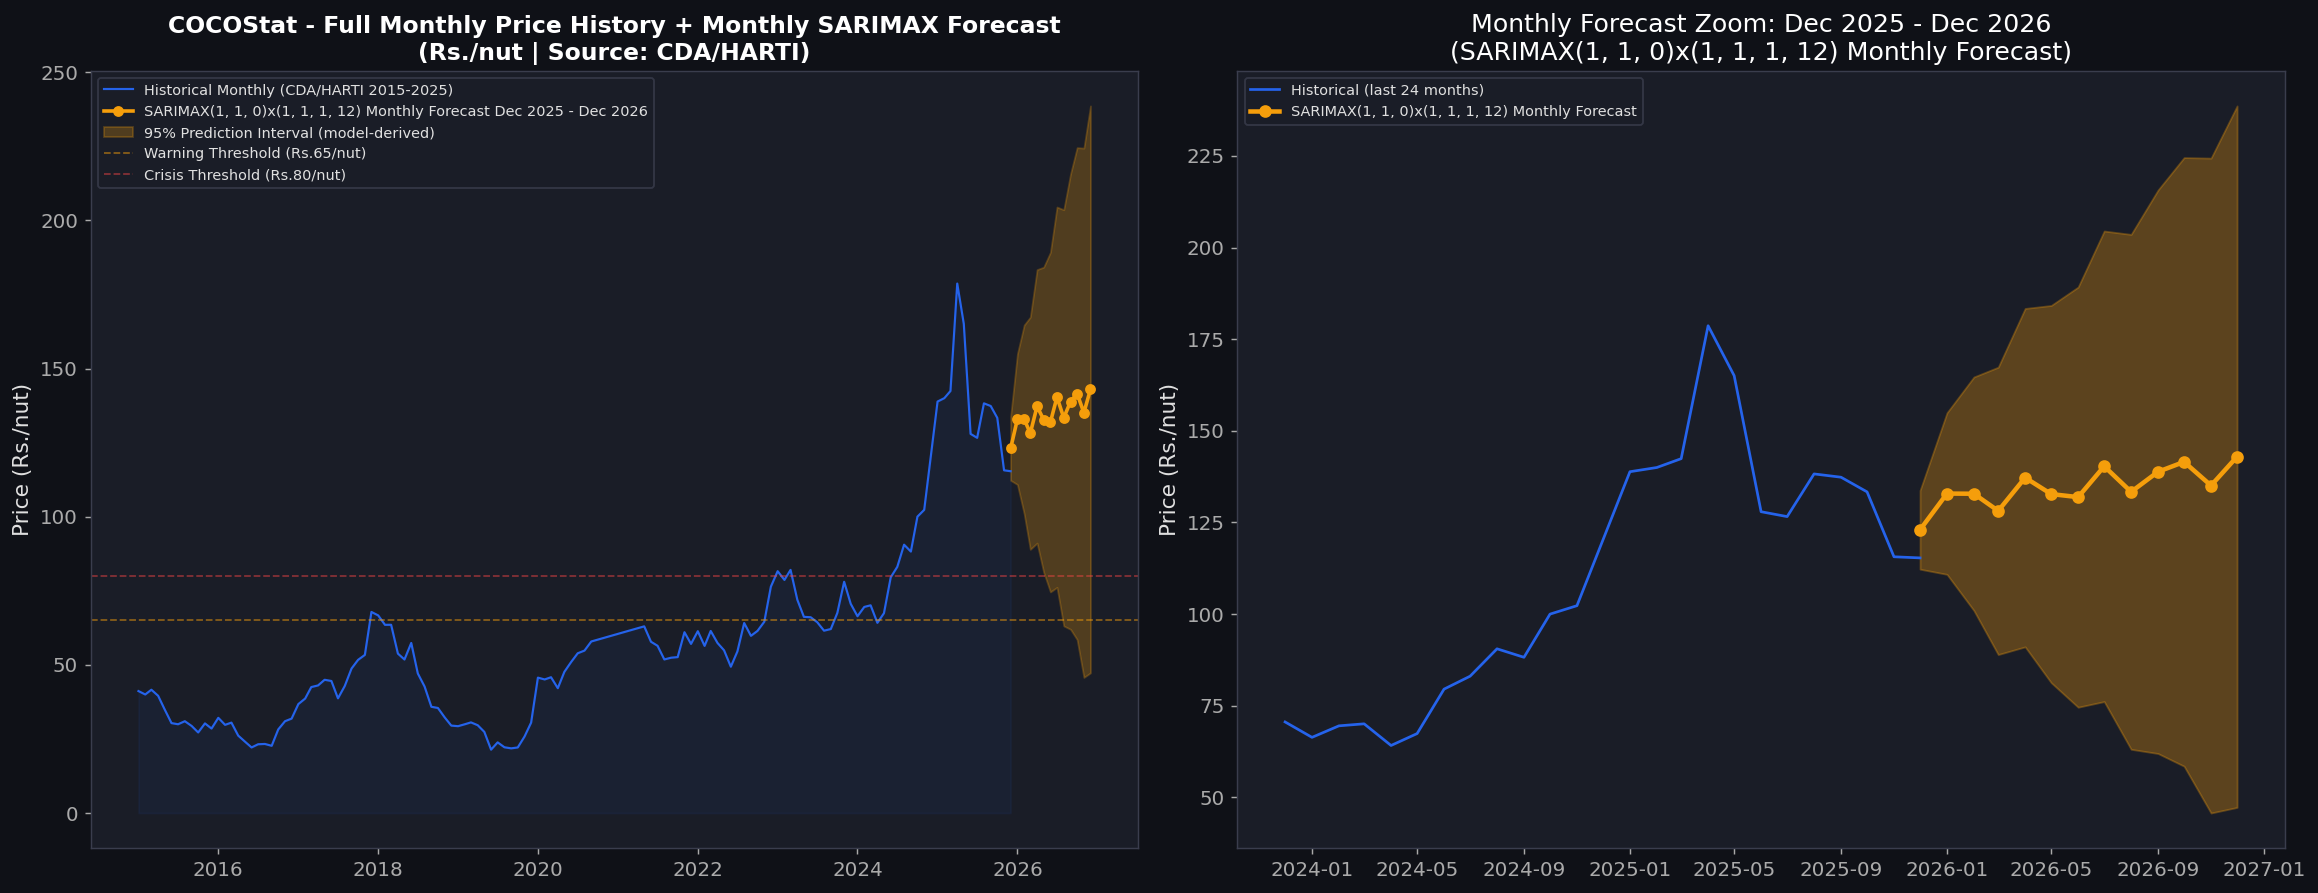

In [28]:
# Final Forecast Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Define forecast variables from monthly aggregated SARIMAX output
fc_dates = pd.to_datetime(monthly_forecast_summary['Month Date'])
fc_values = monthly_forecast_summary['Forecast_Rs_Nut']
fc_upper = monthly_forecast_summary['Upper_95'] / 1000 # Convert back to Rs./Nut
fc_lower = monthly_forecast_summary['Lower_95'] / 1000 # Convert back to Rs./Nut

# Historical monthly data for plotting
hist_dates_monthly = df_monthly_summary['Date_Index']
hist_prices_monthly = df_monthly_summary['Price Per Nut (Rs.)']

# Left: Full historical + dataset forecast
axes[0].plot(hist_dates_monthly, hist_prices_monthly, color='#2563eb', lw=1.2, label='Historical Monthly (CDA/HARTI 2015-2025)')
axes[0].fill_between(hist_dates_monthly, hist_prices_monthly, alpha=0.06, color='#2563eb')
axes[0].plot(fc_dates, fc_values, 'o-', color='#f59e0b', lw=2, markersize=5,
             label=f'SARIMAX{best_order}x{best_sorder} Monthly Forecast {fc_dates.min().strftime("%b %Y")} - {fc_dates.max().strftime("%b %Y")}')
axes[0].fill_between(fc_dates, fc_upper, fc_lower, alpha=0.25, color='#f59e0b',
                     label='95% Prediction Interval (model-derived)')
axes[0].axhline(65, color='#f59e0b', lw=1, ls='--', alpha=0.5, label='Warning Threshold (Rs.65/nut)')
axes[0].axhline(80, color='#ef4444', lw=1, ls='--', alpha=0.5, label='Crisis Threshold (Rs.80/nut)')
axes[0].set_title('COCOStat - Full Monthly Price History + Monthly SARIMAX Forecast\n(Rs./nut | Source: CDA/HARTI)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (Rs./nut)')
axes[0].legend(fontsize=8)

# Right: Zoomed forecast
# Use historical monthly data for the last 24 months for zoom
zoom_dates_hist = hist_dates_monthly[hist_dates_monthly >= hist_dates_monthly.max() - pd.DateOffset(years=2)]
zoom_prices     = hist_prices_monthly[hist_dates_monthly >= hist_dates_monthly.max() - pd.DateOffset(years=2)]

axes[1].plot(zoom_dates_hist, zoom_prices, color='#2563eb', lw=1.5, label='Historical (last 24 months)')
axes[1].plot(fc_dates, fc_values, 'o-', color='#f59e0b', lw=2.5, markersize=6, label=f'SARIMAX{best_order}x{best_sorder} Monthly Forecast')
axes[1].fill_between(fc_dates, fc_upper, fc_lower, alpha=0.3, color='#f59e0b')

# Removed annotation to avoid clutter on monthly plot
# for d_val, base_val in zip(fc_dates, fc_values):
#     axes[1].annotate(f'{base_val:.1f}', xy=(d_val, base_val), xytext=(0, 6),
#                      textcoords='offset points', ha='center', fontsize=7, color='#92400e')

axes[1].set_title(f'Monthly Forecast Zoom: {fc_dates.min().strftime("%b %Y")} - {fc_dates.max().strftime("%b %Y")}\n(SARIMAX{best_order}x{best_sorder} Monthly Forecast)')
axes[1].set_ylabel('Price (Rs./nut)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('task14_monthly_forecast_validation.png', dpi=150, bbox_inches='tight') # Changed filename
plt.show()

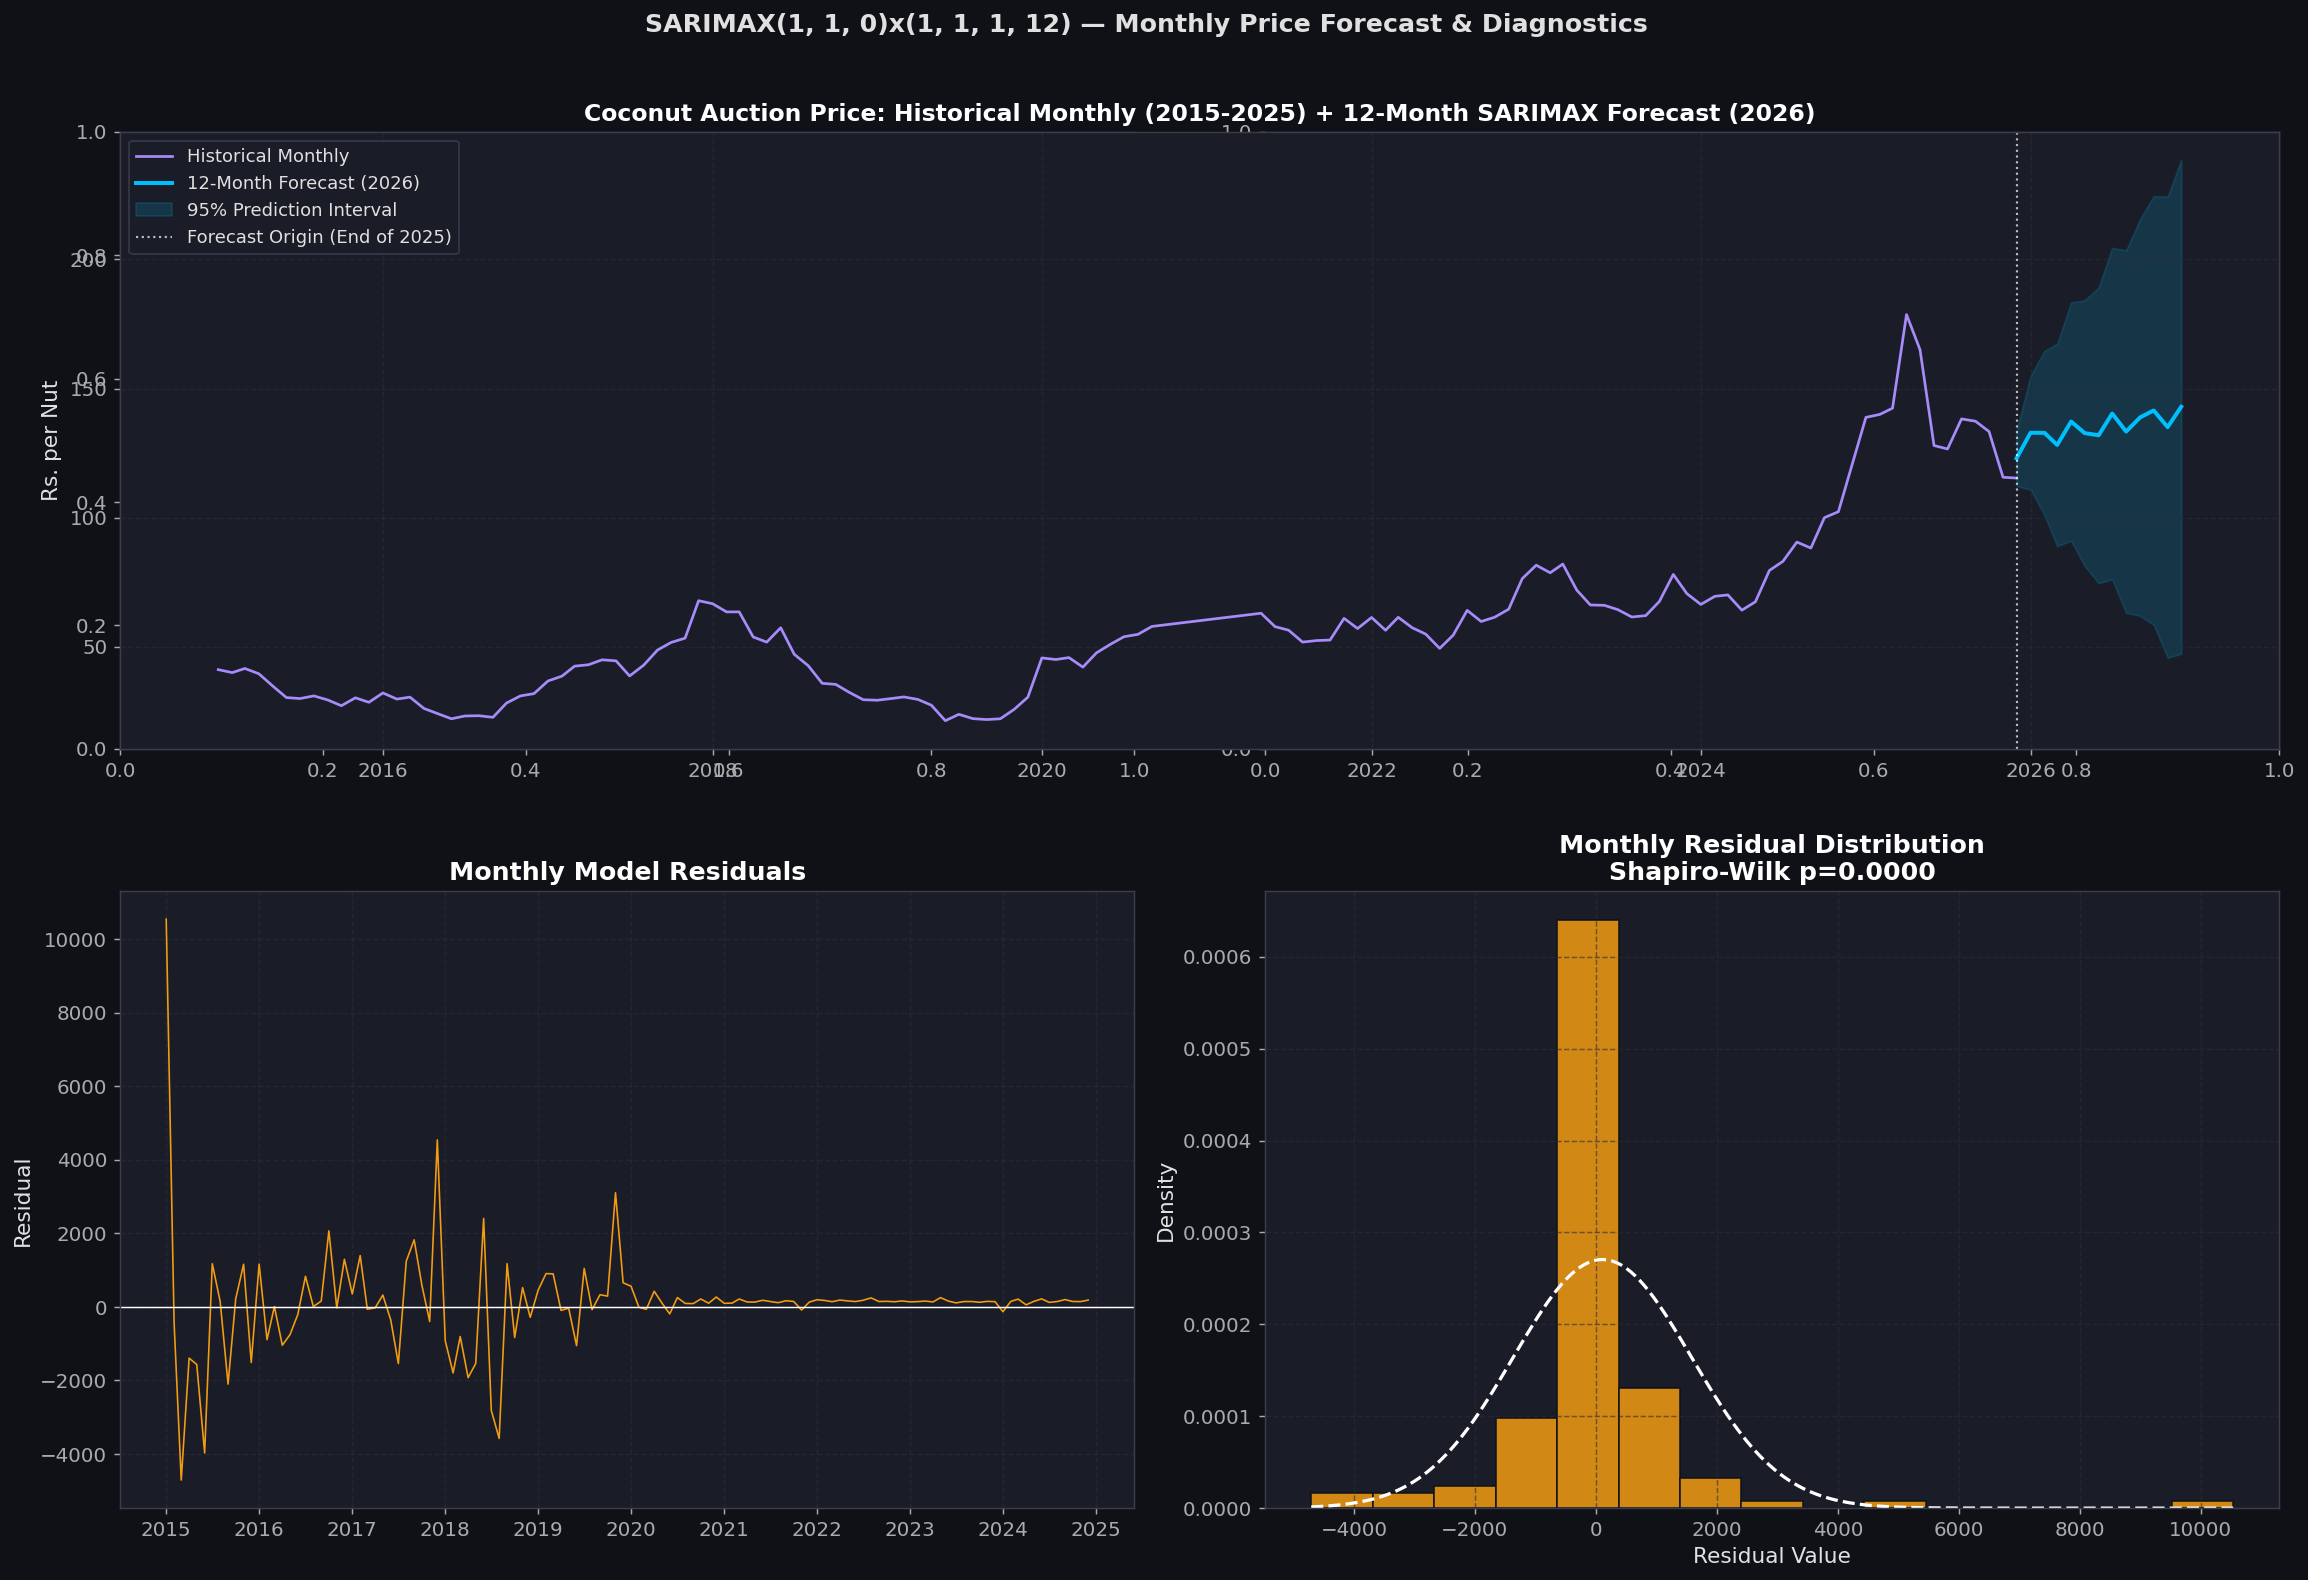

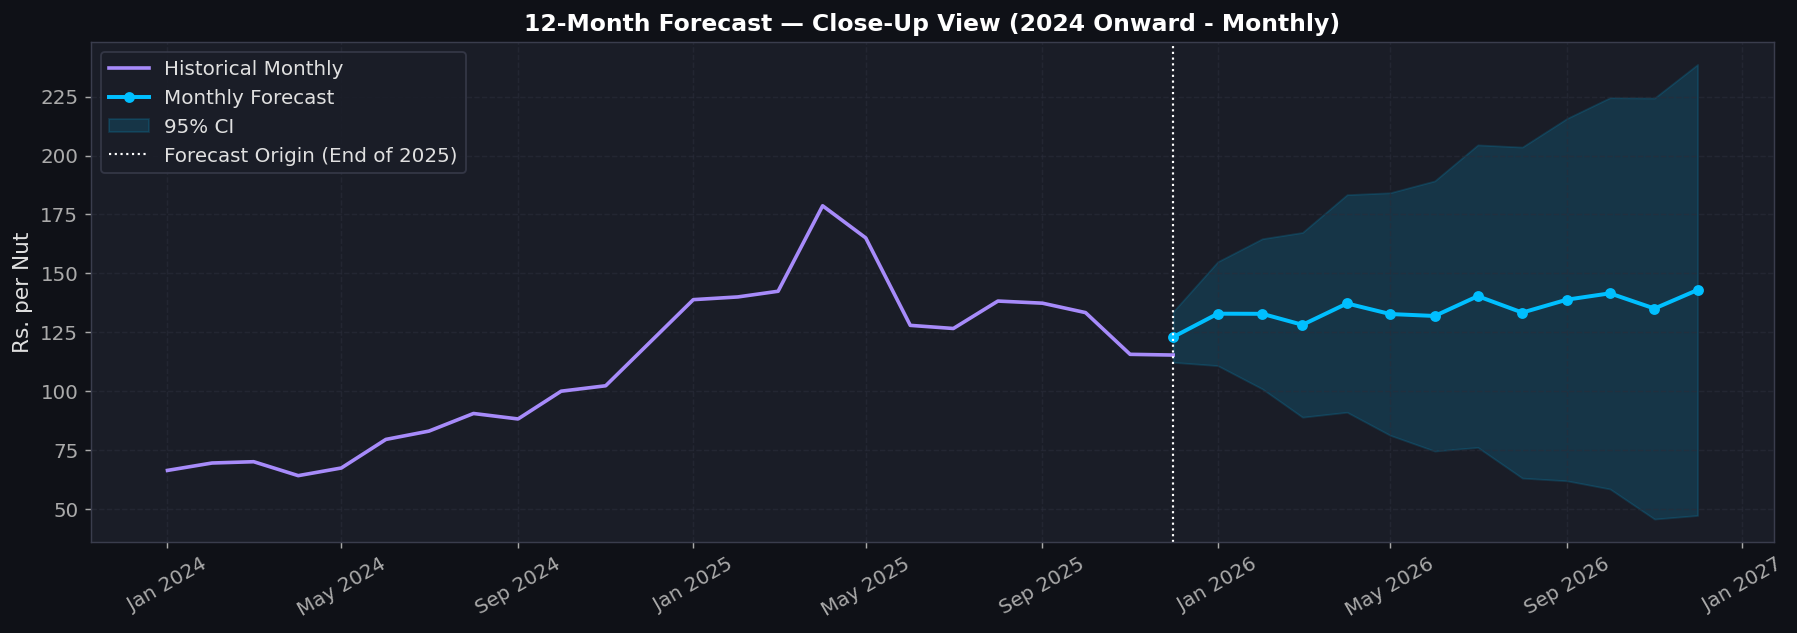

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f'SARIMAX{best_order}x{best_sorder} — Monthly Price Forecast & Diagnostics', fontsize=14, fontweight='bold', y=1.01)

# Prepare monthly historical data and forecast
hist_dates_monthly = df_monthly_summary['Date_Index']
hist_prices_monthly = df_monthly_summary['Price Per Nut (Rs.)']

fc_dates = pd.to_datetime(monthly_forecast_summary['Month Date'])
fc_values = monthly_forecast_summary['Forecast_Rs_Nut']
fc_upper = monthly_forecast_summary['Upper_95'] / 1000  # Already Rs./Nut from previous calculation
fc_lower = monthly_forecast_summary['Lower_95'] / 1000  # Already Rs./Nut from previous calculation

# ── Main forecast plot (Monthly) ──────────────────────────────────────────────
ax1 = fig.add_subplot(2, 1, 1) # Span both columns
ax1.set_facecolor('#1a1d27')

# Historical
ax1.plot(hist_dates_monthly, hist_prices_monthly, color=PALETTE['actual'],
         linewidth=1.5, label='Historical Monthly')

# Forecast (using monthly aggregated data)
ax1.plot(fc_dates, fc_values, color=PALETTE['forecast'],
         linewidth=2.2, label='12-Month Forecast (2026)')

# CI bands
ax1.fill_between(fc_dates, fc_lower, fc_upper,
                 alpha=0.15, color=PALETTE['ci'], label='95% Prediction Interval')

ax1.axvline(hist_dates_monthly.max(), color='white', linewidth=1.2, linestyle=':', alpha=0.7, label='Forecast Origin (End of 2025)')
ax1.set_title('Coconut Auction Price: Historical Monthly (2015-2025) + 12-Month SARIMAX Forecast (2026)', fontweight='bold', fontsize=13)
ax1.set_ylabel('Rs. per Nut')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── Residual diagnostics (Monthly) ──────────────────────────────────────────
# Aggregate weekly residuals to monthly mean residuals
monthly_residuals = residuals.resample('MS').mean().dropna()

ax2 = axes[1,0]
ax2.plot(monthly_residuals.index, monthly_residuals.values, color='#f39c12', linewidth=0.9)
ax2.axhline(0, color='white', linewidth=0.8)
ax2.set_title('Monthly Model Residuals', fontweight='bold')
ax2.set_ylabel('Residual')
ax2.grid(True)

ax3 = axes[1,1]
ax3.hist(monthly_residuals, bins=15, color='#f39c12', edgecolor='#0f1117', density=True, alpha=0.85)
xr_monthly = np.linspace(monthly_residuals.min(), monthly_residuals.max(), 200)
ax3.plot(xr_monthly, stats.norm.pdf(xr_monthly, monthly_residuals.mean(), monthly_residuals.std()), color='white', linewidth=1.8, linestyle='--')

# Shapiro-Wilk test for monthly residuals
sw_stat_monthly, sw_p_monthly = stats.shapiro(monthly_residuals)
ax3.set_title(f'Monthly Residual Distribution\nShapiro-Wilk p={sw_p_monthly:.4f}', fontweight='bold')
ax3.set_xlabel('Residual Value')
ax3.set_ylabel('Density')
ax3.grid(True)

plt.tight_layout()
plt.show()

# ── Close-up monthly forecast ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
cutoff_monthly = pd.Timestamp('2024-01-01') # Start from 2024 for a clearer view

hist_subset_monthly = df_monthly_summary[df_monthly_summary['Date_Index'] >= cutoff_monthly]

ax.plot(hist_subset_monthly['Date_Index'], hist_subset_monthly['Price Per Nut (Rs.)'], color=PALETTE['actual'], linewidth=2, label='Historical Monthly')
ax.plot(fc_dates, fc_values, color=PALETTE['forecast'], linewidth=2.2, marker='o', markersize=5, label='Monthly Forecast')
ax.fill_between(fc_dates, fc_lower, fc_upper, alpha=0.15, color=PALETTE['ci'], label='95% CI')
ax.axvline(hist_dates_monthly.max(), color='white', linewidth=1.2, linestyle=':', label='Forecast Origin (End of 2025)')
ax.set_title('12-Month Forecast — Close-Up View (2024 Onward - Monthly)', fontweight='bold', fontsize=13)
ax.set_ylabel('Rs. per Nut')
ax.legend()
ax.grid(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## 7. Production Analytics

In [24]:
prod = df_prod.copy()
prod_num = prod.apply(pd.to_numeric, errors='coerce')
prod_num['Year'] = prod['Year'].astype(int)

print('PRODUCTION DATA — FULL TABLE')
print('=' * 100)
print(prod_num.to_string(index=False))

print('\nSUMMARY STATISTICS — PRODUCTION')
print('=' * 80)
prod_desc = prod_num.drop('Year',axis=1).describe().round(1).T
prod_desc.columns = ['Count','Mean','Std','Min','25th','Median','75th','Max']
prod_desc.index = ['Total Production (Mn. Nuts)','Copra (MT)','VCO (MT)','DC (MT)','Coconut Milk (MT)','CMP (MT)','Fresh Nuts Local (Mn.)','Seed Coconut (Mn.)']
print(prod_desc.to_string())

PRODUCTION DATA — FULL TABLE
 Year  Total_Production   Copra     VCO      DC  Coconut_Milk     CMP  Fresh_Nuts_Local  Seed_Coconut
 2015           3056.30 76278.0 13765.0 41795.0       30200.0  7500.0           2000.28          3.00
 2016           3011.28 40014.0 16067.0 51117.0       30497.0  8491.0           1786.70          2.42
 2017           2449.53  7700.0 14243.0 29557.0       32867.0  7793.0           1655.51          3.39
 2018           2623.10  6678.0 12377.0 24625.0       34925.0  8669.0           1793.83          3.31
 2019           3085.57 27292.0 12726.0 44081.0       43772.0  9310.0           1806.91          1.92
 2020           2792.20  5178.0 15035.0 25256.0       48068.0  8439.0           1826.15          1.97
 2021           3119.66 22815.0 15423.0 33289.0       54902.0  9303.0           1832.53          3.50
 2022           3250.00 18000.0 16500.0 38000.0       56000.0  9800.0           1890.00          3.80
 2023           3100.00 15000.0 17000.0 36000.0      

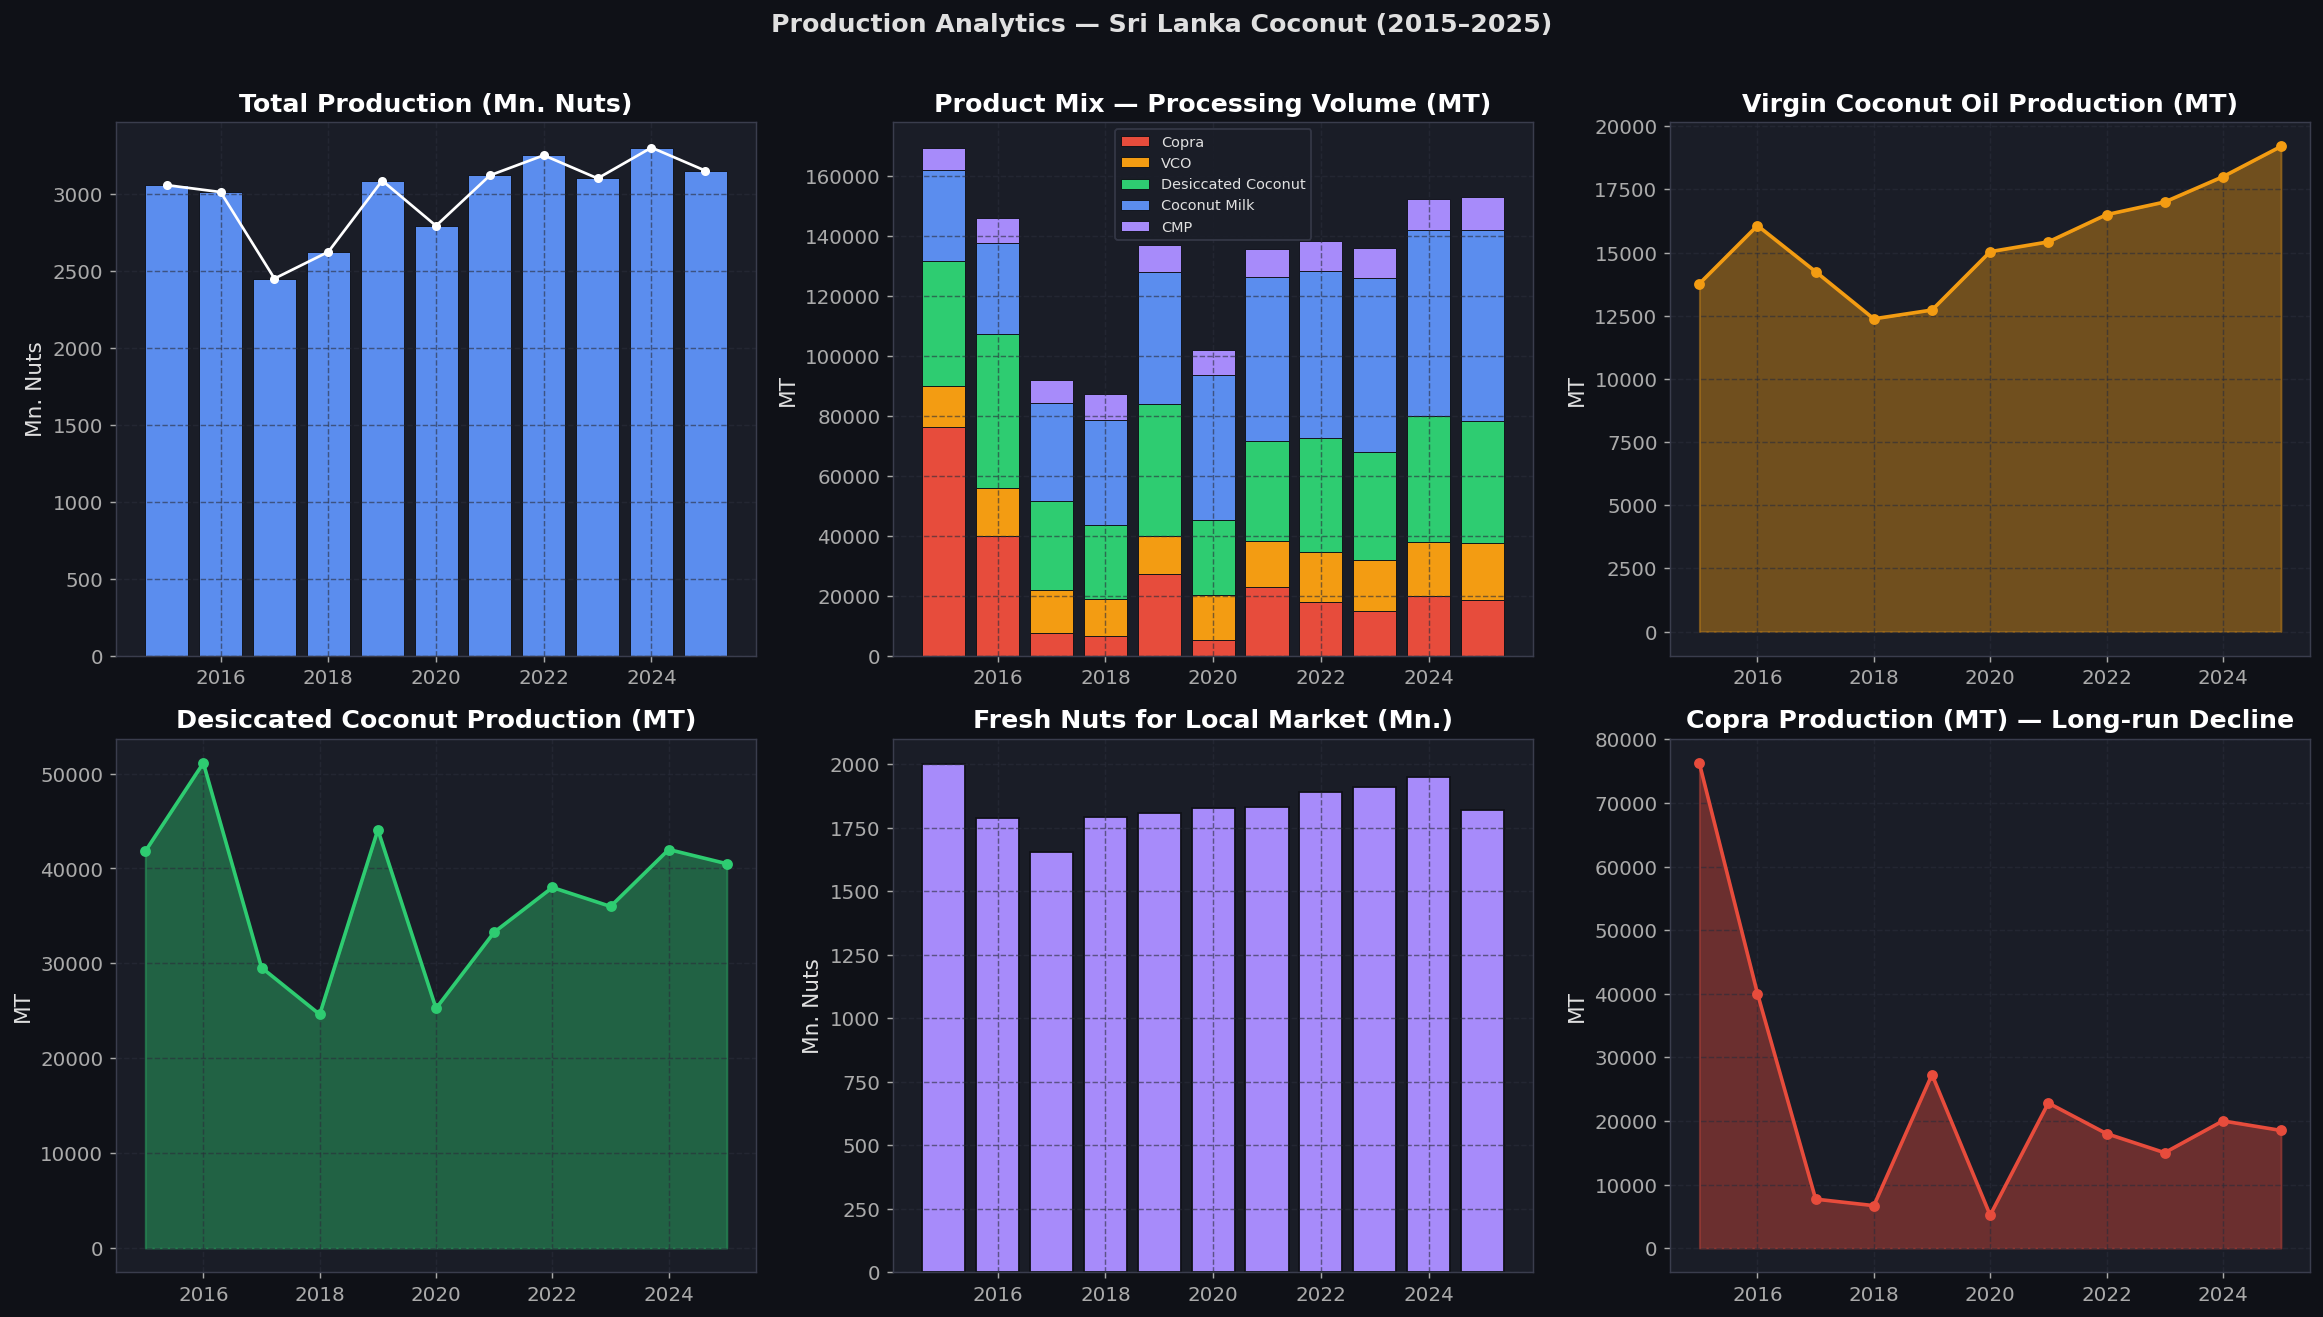

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Production Analytics — Sri Lanka Coconut (2015–2025)', fontsize=14, fontweight='bold', y=1.01)

years = prod_num['Year'].values

# 1. Total production
ax = axes[0,0]
bars = ax.bar(years, prod_num['Total_Production'], color='#5b8dee', edgecolor='#0f1117', linewidth=0.5)
ax.plot(years, prod_num['Total_Production'], color='white', linewidth=1.5, marker='o', markersize=4)
ax.set_title('Total Production (Mn. Nuts)', fontweight='bold')
ax.set_ylabel('Mn. Nuts')
ax.grid(True)

# 2. Product mix stacked bar
ax = axes[0,1]
prods = ['Copra','VCO','DC','Coconut_Milk','CMP']
prod_colors = ['#e74c3c','#f39c12','#2ecc71','#5b8dee','#a78bfa']
prod_labels = ['Copra','VCO','Desiccated Coconut','Coconut Milk','CMP']
bottom = np.zeros(len(years))
for prod_col, col, lbl in zip(prods, prod_colors, prod_labels):
    vals = prod_num[prod_col].fillna(0).values
    ax.bar(years, vals, bottom=bottom, color=col, label=lbl, edgecolor='#0f1117', linewidth=0.5)
    bottom += vals
ax.set_title('Product Mix — Processing Volume (MT)', fontweight='bold')
ax.set_ylabel('MT')
ax.legend(fontsize=8)
ax.grid(True)

# 3. VCO trend
ax = axes[0,2]
ax.fill_between(years, prod_num['VCO'], alpha=0.4, color='#f39c12')
ax.plot(years, prod_num['VCO'], color='#f39c12', linewidth=2, marker='o', markersize=5)
ax.set_title('Virgin Coconut Oil Production (MT)', fontweight='bold')
ax.set_ylabel('MT')
ax.grid(True)

# 4. DC production
ax = axes[1,0]
ax.fill_between(years, prod_num['DC'], alpha=0.4, color='#2ecc71')
ax.plot(years, prod_num['DC'], color='#2ecc71', linewidth=2, marker='o', markersize=5)
ax.set_title('Desiccated Coconut Production (MT)', fontweight='bold')
ax.set_ylabel('MT')
ax.grid(True)

# 5. Fresh nuts local
ax = axes[1,1]
ax.bar(years, prod_num['Fresh_Nuts_Local'].fillna(0), color='#a78bfa', edgecolor='#0f1117')
ax.set_title('Fresh Nuts for Local Market (Mn.)', fontweight='bold')
ax.set_ylabel('Mn. Nuts')
ax.grid(True)

# 6. Copra decline
ax = axes[1,2]
ax.fill_between(years, prod_num['Copra'], alpha=0.4, color='#e74c3c')
ax.plot(years, prod_num['Copra'], color='#e74c3c', linewidth=2, marker='o', markersize=5)
ax.set_title('Copra Production (MT) — Long-run Decline', fontweight='bold')
ax.set_ylabel('MT')
ax.grid(True)

plt.tight_layout()
plt.show()

---
## 8. Export Analytics

In [38]:
exp = df_export.copy()
exp_num = exp.apply(pd.to_numeric, errors='coerce')
exp_num['Year'] = exp['Year'].astype(int)

print('EXPORT VOLUME TABLE')
print('=' * 100)
print(exp_num.to_string(index=False))

# CAGR calculation
exp_valid = exp_num[exp_num['Year'].between(2015,2025)]
if len(exp_valid) >= 2:
    n = exp_valid['Year'].max() - exp_valid['Year'].min()
    first_total = exp_valid.iloc[0]['Total_Export_MT']
    last_total  = exp_valid.iloc[-1]['Total_Export_MT']
    cagr = ((last_total / first_total) ** (1/n) - 1) * 100 if first_total and n > 0 else np.nan
    print(f'\nTotal Export CAGR (2015-{exp_valid["Year"].max()}): {cagr:.1f}%')

EXPORT VOLUME TABLE
 Year   DC_MT  CocoOil_MT  CMP_MT  Coir_MT  FreshNuts_1000  Copra_MT  CocoMilk_MT  CocoCream_MT  Total_Export_MT
 2013 28202.0      1720.0 12570.0     2101         21456.0    1371.0        12570       12591.0          46255.0
 2014 51132.0      3976.0 15491.0     7278         33037.0    4776.0        15491       11923.0          84576.0
 2015 36131.0      8679.0 21957.0    13353         13204.0    2489.0        21957       21874.0          83483.0
 2016 49206.0      7094.0 30497.0    15585         30433.0    1184.0        30497       13652.0         107218.0
 2017 29418.0      6310.0 32867.0    13816         10232.0    4501.0        32867       16446.0          95592.0
 2018 25556.0      4606.0 31267.0    12006          1433.0    2629.0        31267       19782.0          90835.0
 2019 49667.0      4056.0 36396.0    12344         21426.0    3915.0        36396       10987.0         117365.0
 2020 29591.0      5180.0 46626.0    14584         15838.0    1082.0        

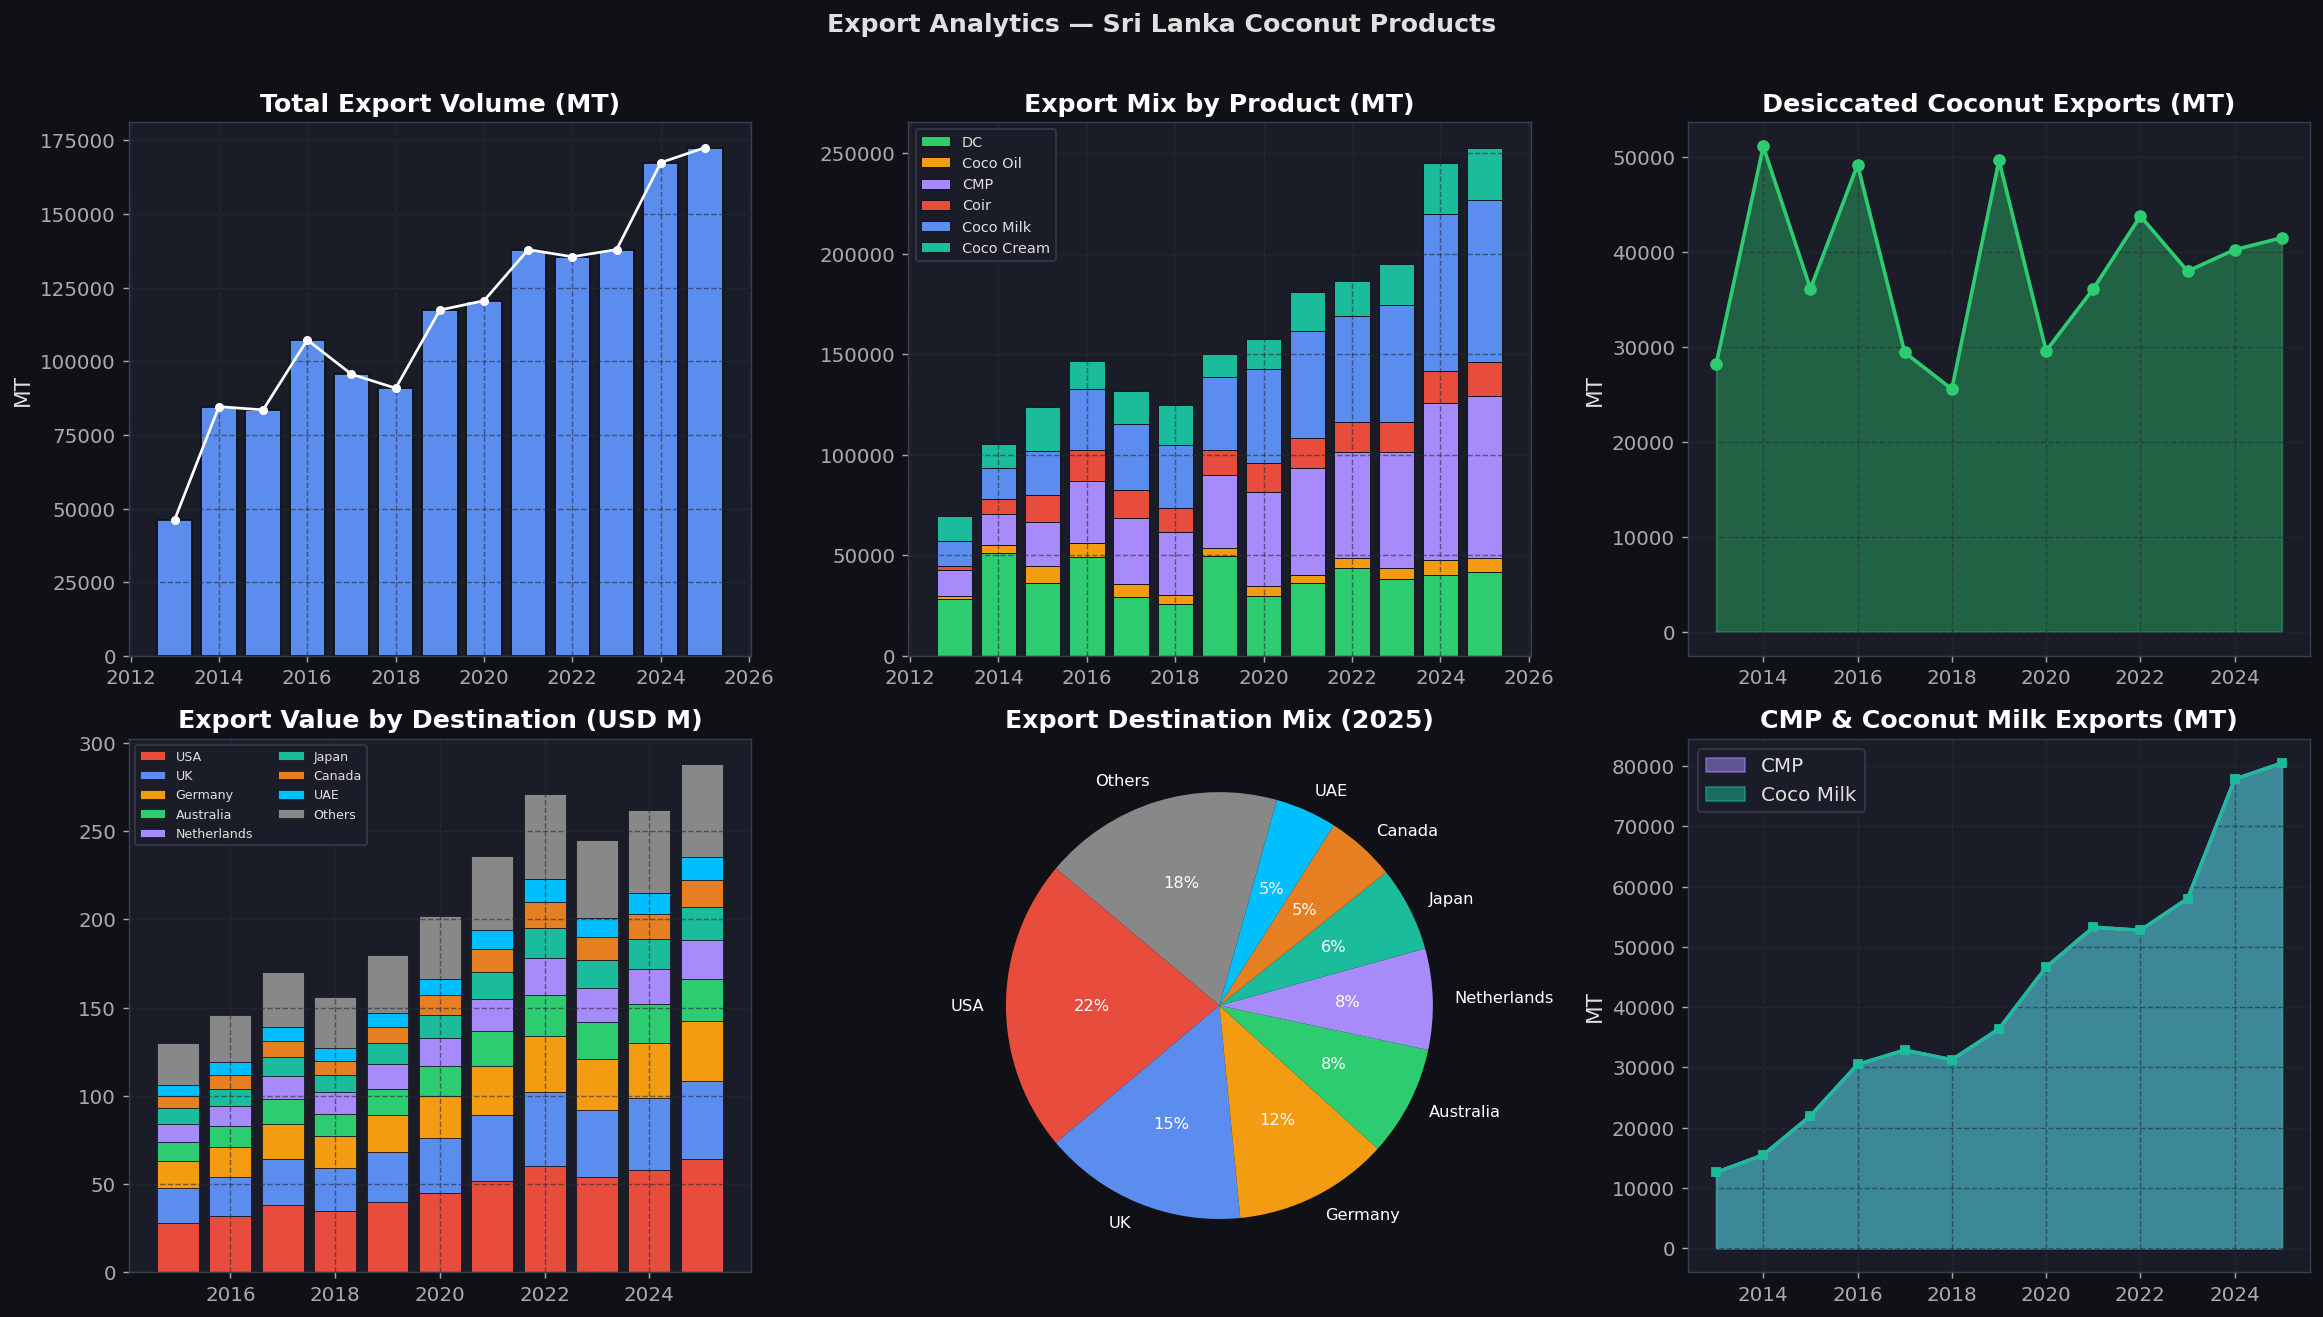

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Export Analytics — Sri Lanka Coconut Products', fontsize=14, fontweight='bold', y=1.01)

years_exp = exp_num['Year'].values

# 1. Total export volume
ax = axes[0,0]
ax.bar(years_exp, exp_num['Total_Export_MT'], color='#5b8dee', edgecolor='#0f1117')
ax.plot(years_exp, exp_num['Total_Export_MT'], color='white', linewidth=1.5, marker='o', markersize=4)
ax.set_title('Total Export Volume (MT)', fontweight='bold')
ax.set_ylabel('MT')
ax.grid(True)

# 2. Export mix stacked
ax = axes[0,1]
exp_cats = ['DC_MT','CocoOil_MT','CMP_MT','Coir_MT','CocoMilk_MT','CocoCream_MT']
exp_clrs = ['#2ecc71','#f39c12','#a78bfa','#e74c3c','#5b8dee','#1abc9c']
exp_lbls = ['DC','Coco Oil','CMP','Coir','Coco Milk','Coco Cream']
bot = np.zeros(len(years_exp))
for col,clr,lbl in zip(exp_cats,exp_clrs,exp_lbls):
    v = exp_num[col].fillna(0).values
    ax.bar(years_exp, v, bottom=bot, color=clr, label=lbl, edgecolor='#0f1117', linewidth=0.5)
    bot += v
ax.set_title('Export Mix by Product (MT)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True)

# 3. DC export trend
ax = axes[0,2]
ax.fill_between(years_exp, exp_num['DC_MT'], alpha=0.4, color='#2ecc71')
ax.plot(years_exp, exp_num['DC_MT'], color='#2ecc71', linewidth=2, marker='o')
ax.set_title('Desiccated Coconut Exports (MT)', fontweight='bold')
ax.set_ylabel('MT')
ax.grid(True)

# 4. Export destinations
dest = df_dest.copy()
dest_num = dest.apply(pd.to_numeric, errors='coerce')
dest_num['Year'] = dest['Year'].astype(int)
dest_cols = ['USA','UK','Germany','Australia','Netherlands','Japan','Canada','UAE','Others']

ax = axes[1,0]
dest_colors = ['#e74c3c','#5b8dee','#f39c12','#2ecc71','#a78bfa','#1abc9c','#e67e22','#00bfff','#888']
bot = np.zeros(len(dest_num))
for col,clr in zip(dest_cols,dest_colors):
    v = dest_num[col].fillna(0).values
    ax.bar(dest_num['Year'].values, v, bottom=bot, color=clr, label=col, edgecolor='#0f1117', linewidth=0.4)
    bot += v
ax.set_title('Export Value by Destination (USD M)', fontweight='bold')
ax.legend(fontsize=7, ncol=2)
ax.grid(True)

# 5. Top destinations pie (latest year)
ax = axes[1,1]
latest_dest = dest_num.iloc[-1][dest_cols]
pie_vals = latest_dest.values
ax.pie(pie_vals, labels=dest_cols, colors=dest_colors, autopct='%1.0f%%',
       startangle=140, textprops={'color':'white','fontsize':9})
ax.set_title(f'Export Destination Mix ({dest_num["Year"].iloc[-1]})', fontweight='bold')

# 6. CMP + CocoMilk
ax = axes[1,2]
ax.fill_between(years_exp, exp_num['CMP_MT'], alpha=0.5, color='#a78bfa', label='CMP')
ax.fill_between(years_exp, exp_num['CocoMilk_MT'], alpha=0.5, color='#1abc9c', label='Coco Milk')
ax.plot(years_exp, exp_num['CMP_MT'], color='#a78bfa', linewidth=1.8, marker='o', markersize=4)
ax.plot(years_exp, exp_num['CocoMilk_MT'], color='#1abc9c', linewidth=1.8, marker='s', markersize=4)
ax.set_title('CMP & Coconut Milk Exports (MT)', fontweight='bold')
ax.set_ylabel('MT')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

---
## 9. Weather, Yield & Climate Impact

In [40]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
wx = df_weather.copy()
wx['Month_Num'] = wx['Month'].map({m: i+1 for i,m in enumerate(month_order)})
wx['Date'] = pd.to_datetime(wx['Year'].astype(str) + '-' + wx['Month_Num'].astype(str).str.zfill(2) + '-01')
wx = wx.sort_values('Date').reset_index(drop=True)
wx['Drought'] = wx['Drought_Flag'].notna().astype(int)

# Correlation of weather variables with price
# df_monthly was created in an earlier step but not in the main data loading block
# Re-create df_monthly for this cell for robustness
df_monthly = df_weekly.groupby(['Year', df_weekly['Date'].dt.month_name().str[:3]]).agg(
    Avg_Price=('Avg_Price', 'mean')
).reset_index()
df_monthly.rename(columns={'Date': 'Month'}, inplace=True)

# Map month names to full datetime for proper merging
df_monthly['Date'] = pd.to_datetime(df_monthly['Year'].astype(str) + '-' + df_monthly['Month'], format='%Y-%b')

wx_price = wx.merge(df_monthly[['Date','Avg_Price']], on='Date', how='inner')
corr_matrix = wx_price[['Avg_Price','Rainfall','Temperature','Yield_Index','Lag3_Rain','Drought']].corr()

print('WEATHER-PRICE CORRELATION MATRIX')
print('=' * 70)
print(corr_matrix.round(4).to_string())

print('\n\nWEATHER SUMMARY BY YEAR')
print('=' * 80)
wx_annual = wx.groupby('Year').agg(
    Avg_Rainfall=('Rainfall','mean'),
    Total_Rainfall=('Rainfall','sum'),
    Avg_Temperature=('Temperature','mean'),
    Avg_Yield_Index=('Yield_Index','mean'),
    Drought_Months=('Drought','sum')
).round(2)
print(wx_annual.to_string())

WEATHER-PRICE CORRELATION MATRIX
             Avg_Price  Rainfall  Temperature  Yield_Index  Lag3_Rain  Drought
Avg_Price       1.0000    0.0072      -0.0444      -0.0649     0.0030  -0.0270
Rainfall        0.0072    1.0000       0.7128      -0.1216    -0.1821  -0.7706
Temperature    -0.0444    0.7128       1.0000       0.4223     0.3555  -0.6057
Yield_Index    -0.0649   -0.1216       0.4223       1.0000     0.9262  -0.0817
Lag3_Rain       0.0030   -0.1821       0.3555       0.9262     1.0000   0.0000
Drought        -0.0270   -0.7706      -0.6057      -0.0817     0.0000   1.0000


WEATHER SUMMARY BY YEAR
      Avg_Rainfall  Total_Rainfall  Avg_Temperature  Avg_Yield_Index  Drought_Months
Year                                                                                
2015        108.89          1306.7            27.96            62.32               5
2016         85.76          1029.1            27.91            56.22               5
2017         94.20          1130.4            27

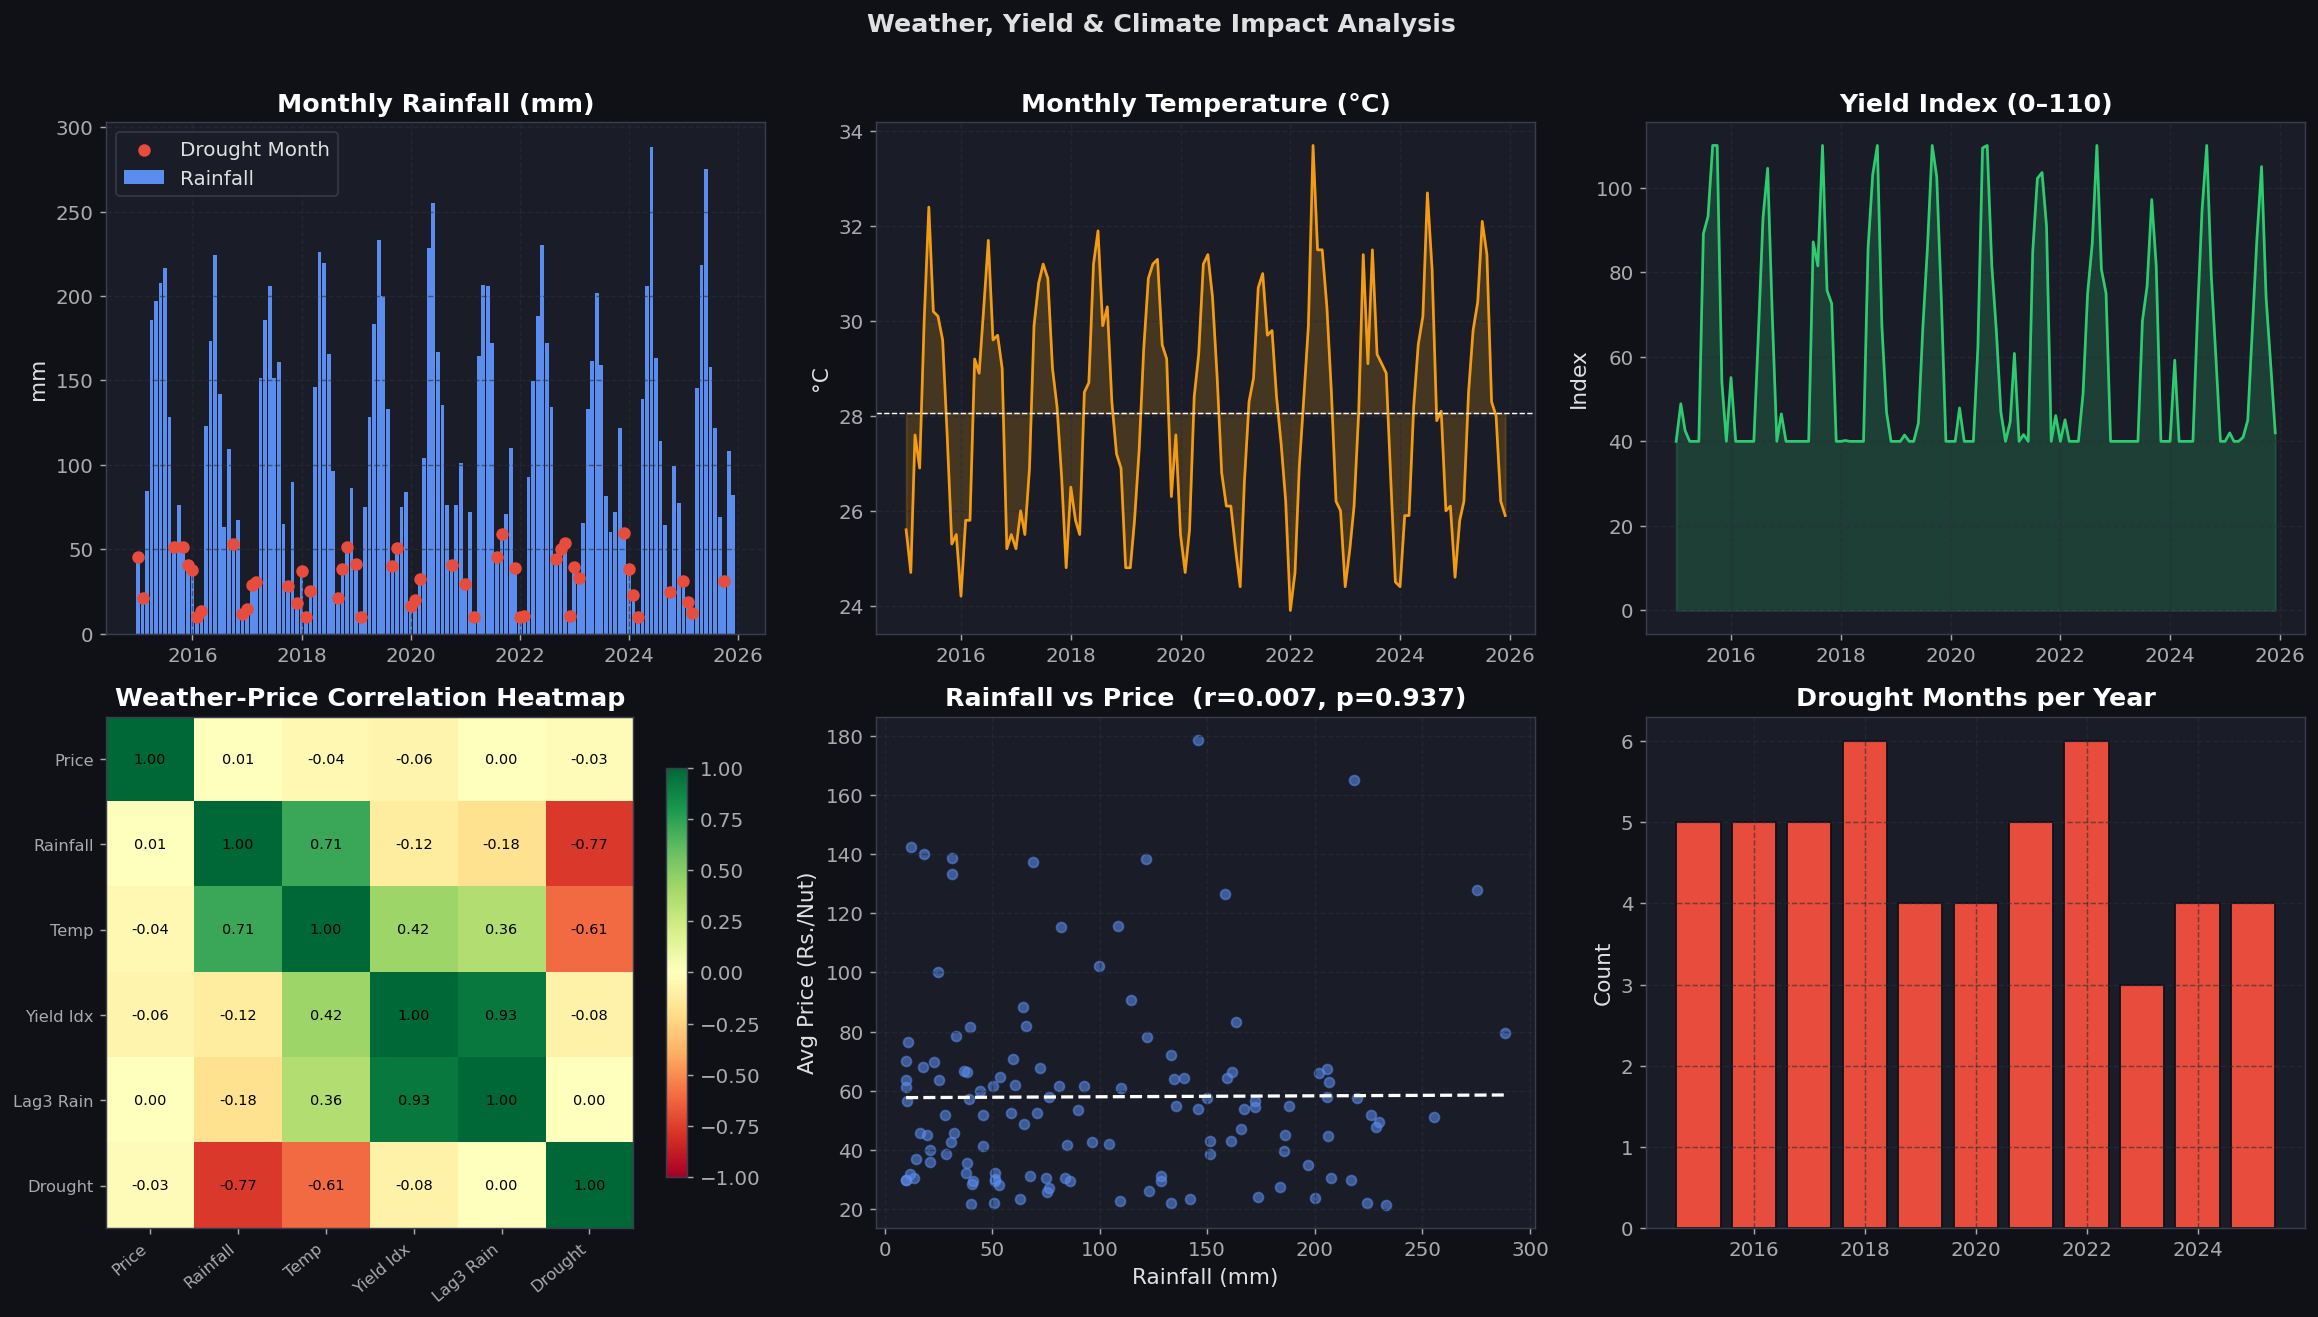

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Weather, Yield & Climate Impact Analysis', fontsize=14, fontweight='bold', y=1.01)

# 1. Rainfall
ax = axes[0,0]
drought_mask = wx['Drought'] == 1
ax.bar(wx['Date'], wx['Rainfall'], color='#5b8dee', width=25, label='Rainfall')
ax.scatter(wx.loc[drought_mask,'Date'], wx.loc[drought_mask,'Rainfall'],
           color='#e74c3c', zorder=3, s=35, label='Drought Month')
ax.set_title('Monthly Rainfall (mm)', fontweight='bold')
ax.set_ylabel('mm')
ax.legend()
ax.grid(True)

# 2. Temperature
ax = axes[0,1]
ax.plot(wx['Date'], wx['Temperature'], color='#f39c12', linewidth=1.5)
ax.fill_between(wx['Date'], wx['Temperature'], wx['Temperature'].mean(), alpha=0.2, color='#f39c12')
ax.axhline(wx['Temperature'].mean(), color='white', linewidth=0.8, linestyle='--')
ax.set_title('Monthly Temperature (°C)', fontweight='bold')
ax.set_ylabel('°C')
ax.grid(True)

# 3. Yield Index
ax = axes[0,2]
ax.plot(wx['Date'], wx['Yield_Index'], color='#2ecc71', linewidth=1.5)
ax.fill_between(wx['Date'], wx['Yield_Index'], alpha=0.2, color='#2ecc71')
ax.set_title('Yield Index (0–110)', fontweight='bold')
ax.set_ylabel('Index')
ax.grid(True)

# 4. Correlation heatmap
ax = axes[1,0]
corr_sub = corr_matrix.values
labels_c = ['Price','Rainfall','Temp','Yield Idx','Lag3 Rain','Drought']
im = ax.imshow(corr_sub, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(labels_c))); ax.set_xticklabels(labels_c, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(labels_c))); ax.set_yticklabels(labels_c, fontsize=9)
for i in range(len(labels_c)):
    for j in range(len(labels_c)):
        ax.text(j,i,f'{corr_sub[i,j]:.2f}', ha='center', va='center', fontsize=8, color='black')
ax.set_title('Weather-Price Correlation Heatmap', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)

# 5. Rainfall vs Price scatter
ax = axes[1,1]
clean_data = wx_price[['Rainfall', 'Avg_Price']].dropna()
ax.scatter(clean_data['Rainfall'], clean_data['Avg_Price']/1000, color='#5b8dee', alpha=0.55, s=30)
m,b = np.polyfit(clean_data['Rainfall'], clean_data['Avg_Price']/1000, 1)
xr = np.linspace(clean_data['Rainfall'].min(), clean_data['Rainfall'].max(), 100)
ax.plot(xr, m*xr+b, color='white', linewidth=1.8, linestyle='--')
r,p = stats.pearsonr(clean_data['Rainfall'], clean_data['Avg_Price']/1000)
ax.set_title(f'Rainfall vs Price  (r={r:.3f}, p={p:.3f})', fontweight='bold')
ax.set_xlabel('Rainfall (mm)')
ax.set_ylabel('Avg Price (Rs./Nut)')
ax.grid(True)

# 6. Annual drought months
ax = axes[1,2]
ax.bar(wx_annual.index, wx_annual['Drought_Months'], color='#e74c3c', edgecolor='#0f1117')
ax.set_title('Drought Months per Year', fontweight='bold')
ax.set_ylabel('Count')
ax.grid(True)

plt.tight_layout()
plt.show()

---
## 10. Global Benchmark Comparison

In [42]:
gcmp = df_gcmp.copy()
gcmp_num = gcmp.apply(pd.to_numeric, errors='coerce')
gcmp_num['Year'] = gcmp['Year'].astype(int)

gb = df_global.copy()
gb_num = gb.apply(pd.to_numeric, errors='coerce')
gb_num['Year'] = gb['Year'].astype(int)

print('GLOBAL FARMGATE PRICE COMPARISON (Rs./Nut equivalent)')
print('=' * 80)
print(gcmp_num.to_string(index=False))

print('\n\nGLOBAL BENCHMARKS — SL vs WORLD')
print('=' * 80)
print(gb_num.to_string(index=False))

GLOBAL FARMGATE PRICE COMPARISON (Rs./Nut equivalent)
 Year     SL  Indonesia  Philippines  India  Vietnam  SL_vs_World_Avg
 2015  41.00       38.0         45.0   48.0     35.0              NaN
 2016  57.00       40.0         47.0   50.0     37.0              NaN
 2017  61.00       42.0         50.0   53.0     39.0              NaN
 2018  65.00       45.0         53.0   56.0     42.0              NaN
 2019  72.00       48.0         56.0   59.0     44.0              NaN
 2020  78.00       50.0         59.0   62.0     47.0              NaN
 2021  93.00       55.0         65.0   68.0     55.0              NaN
 2022 105.00       62.0         73.0   76.0     56.0              NaN
 2023  88.00       58.0         68.0   72.0     53.0              NaN
 2024  95.00       63.0         72.0   76.0     57.0              NaN
 2025 138.29       88.5         72.3   95.4     64.2              NaN


GLOBAL BENCHMARKS — SL vs WORLD
 Year  World_CocoOil_USD  SL_Yield  Land_Ha  Land_Ac  SL_Avg_Price  YoY_

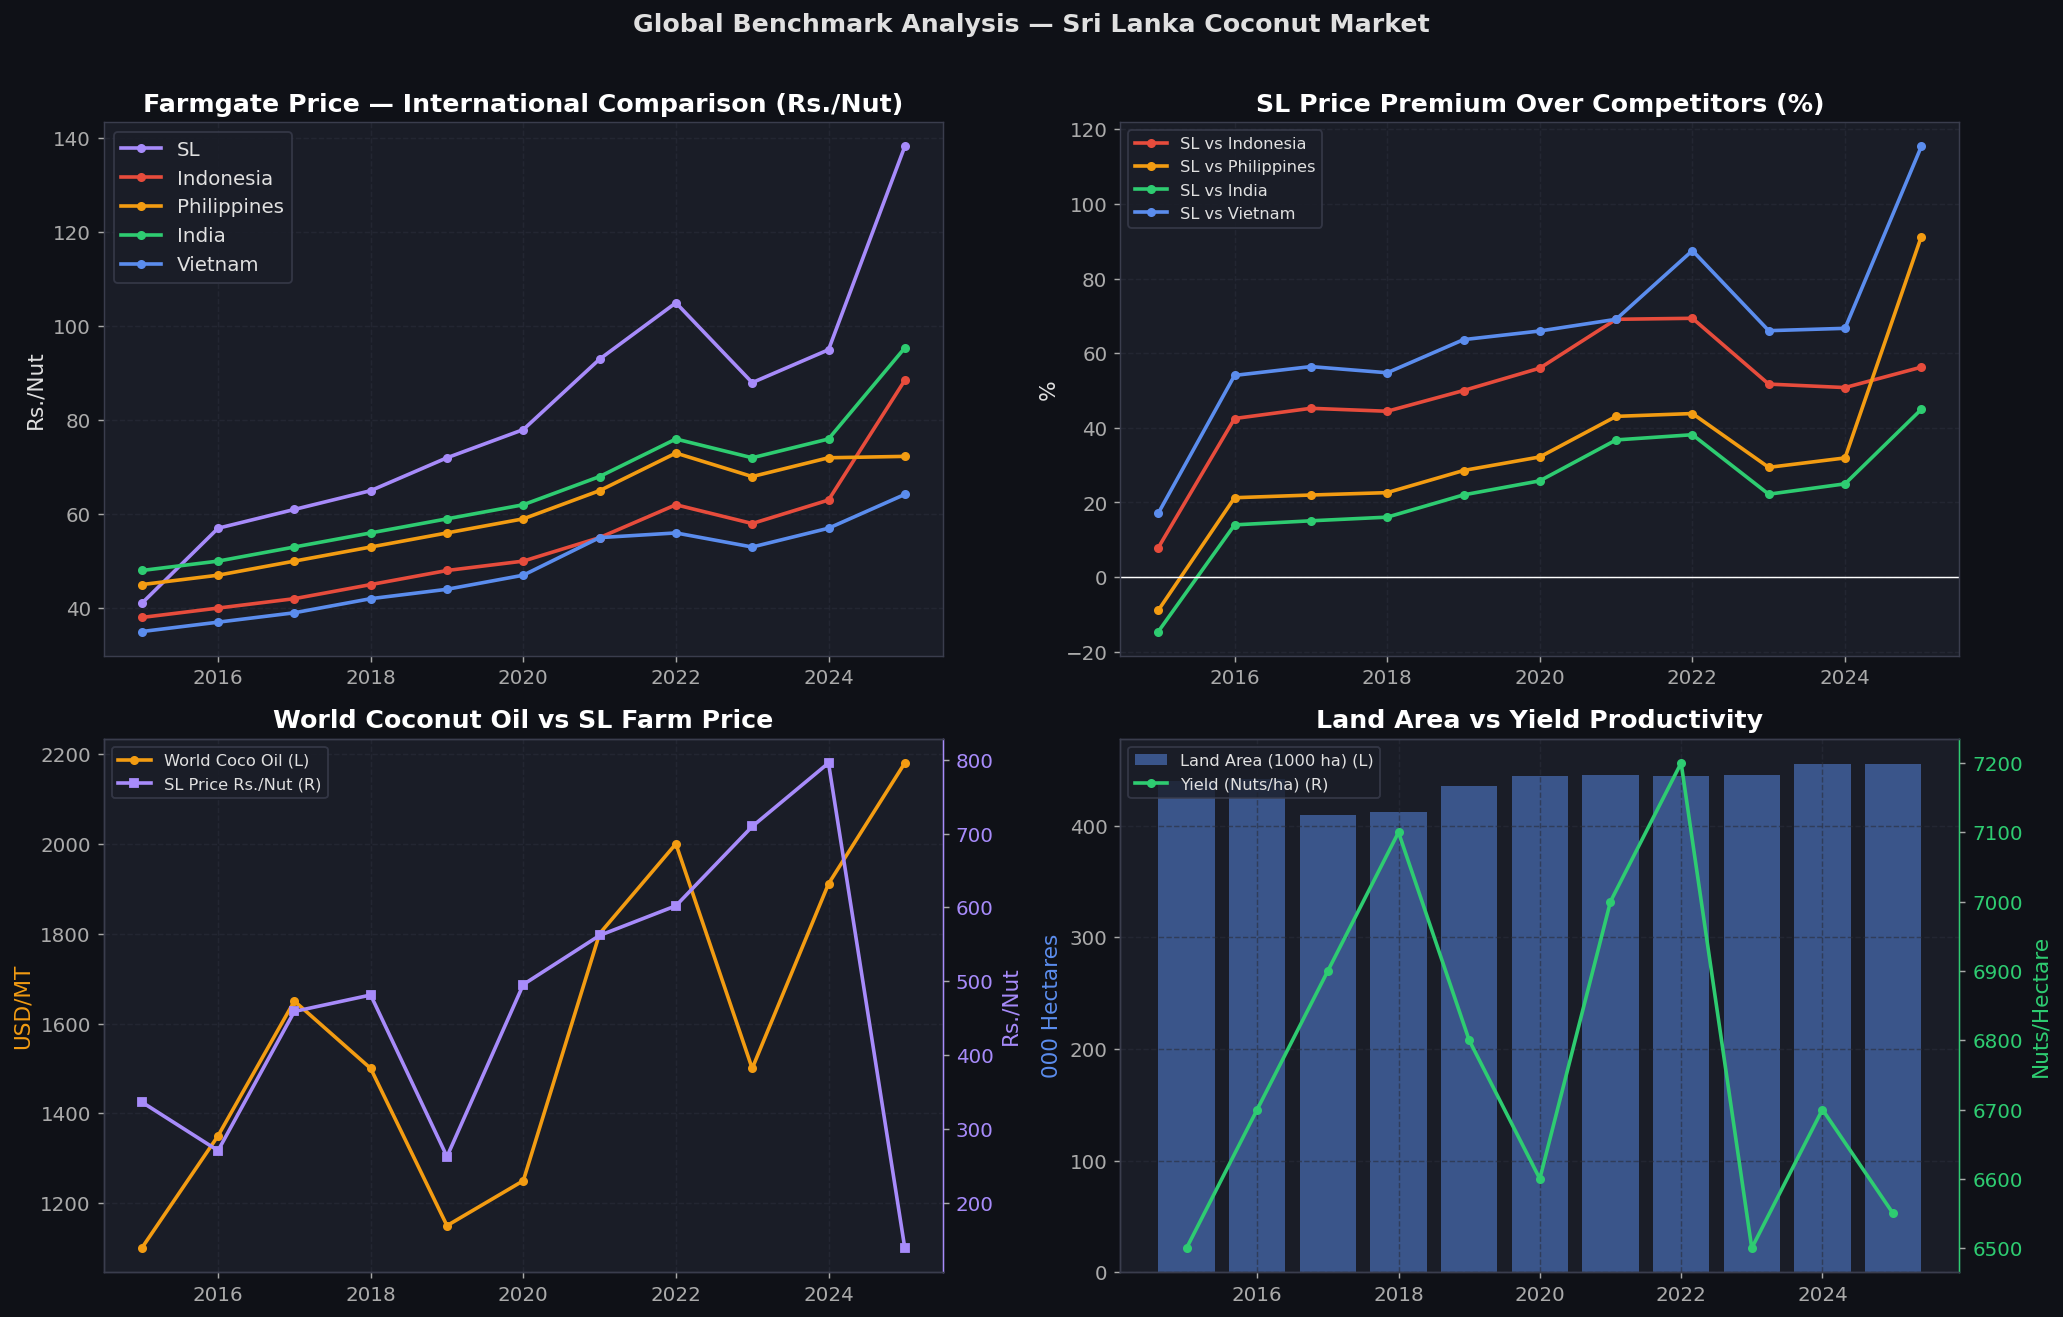

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Global Benchmark Analysis — Sri Lanka Coconut Market', fontsize=14, fontweight='bold', y=1.01)

country_cols = ['SL','Indonesia','Philippines','India','Vietnam']
country_clrs = ['#a78bfa','#e74c3c','#f39c12','#2ecc71','#5b8dee']
years_g = gcmp_num['Year'].values

# 1. Price comparison line
ax = axes[0,0]
for col,clr in zip(country_cols, country_clrs):
    ax.plot(years_g, gcmp_num[col], color=clr, linewidth=2, marker='o', markersize=4, label=col)
ax.set_title('Farmgate Price — International Comparison (Rs./Nut)', fontweight='bold')
ax.set_ylabel('Rs./Nut')
ax.legend()
ax.grid(True)

# 2. SL premium over others
ax = axes[0,1]
for col,clr in zip(country_cols[1:], country_clrs[1:]):
    premium = ((gcmp_num['SL'] - gcmp_num[col]) / gcmp_num[col] * 100)
    ax.plot(years_g, premium, color=clr, linewidth=2, marker='o', markersize=4, label=f'SL vs {col}')
ax.axhline(0, color='white', linewidth=0.8)
ax.set_title('SL Price Premium Over Competitors (%)', fontweight='bold')
ax.set_ylabel('%')
ax.legend(fontsize=9)
ax.grid(True)

# 3. World coconut oil price vs SL
ax = axes[1,0]
ax2 = ax.twinx()
ax.plot(gb_num['Year'], gb_num['World_CocoOil_USD'], color='#f39c12', linewidth=2, marker='o', markersize=4, label='World Coco Oil (L)')
ax2.plot(gb_num['Year'], gb_num['SL_Avg_Price'], color='#a78bfa', linewidth=2, marker='s', markersize=4, label='SL Price Rs./Nut (R)')
ax.set_title('World Coconut Oil vs SL Farm Price', fontweight='bold')
ax.set_ylabel('USD/MT', color='#f39c12')
ax2.set_ylabel('Rs./Nut', color='#a78bfa')
ax2.tick_params(axis='y', labelcolor='#a78bfa')
ax2.spines['right'].set_color('#a78bfa')
l1,lb1 = ax.get_legend_handles_labels()
l2,lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=9)
ax.grid(True)

# 4. SL yield vs land area
ax = axes[1,1]
ax2 = ax.twinx()
ax.bar(gb_num['Year'], gb_num['Land_Ha']/1000, color='#5b8dee', alpha=0.5, label='Land Area (1000 ha) (L)')
ax2.plot(gb_num['Year'], gb_num['SL_Yield'], color='#2ecc71', linewidth=2, marker='o', markersize=4, label='Yield (Nuts/ha) (R)')
ax.set_title('Land Area vs Yield Productivity', fontweight='bold')
ax.set_ylabel('000 Hectares', color='#5b8dee')
ax2.set_ylabel('Nuts/Hectare', color='#2ecc71')
ax2.tick_params(axis='y', labelcolor='#2ecc71')
ax2.spines['right'].set_color('#2ecc71')
l1,lb1 = ax.get_legend_handles_labels()
l2,lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.show()

---
## 11. Seasonality & Demand-Side Analysis

In [44]:
# ── Monthly seasonality ───────────────────────────────────────────────────────
seasonal = df_weekly.groupby('Month').agg(
    Avg_Price=('Avg_Price','mean'),
    Std_Price=('Avg_Price','std'),
    Avg_STR=('Sell_Through_Rate','mean'),
    Avg_Offered=('Offered_Nuts','mean'),
).reindex(month_order).round(2)
seasonal['Seasonal_Index'] = (seasonal['Avg_Price'] / seasonal['Avg_Price'].mean() * 100).round(2)

print('MONTHLY SEASONALITY TABLE')
print('=' * 80)
print(seasonal.to_string())

MONTHLY SEASONALITY TABLE
       Avg_Price  Std_Price  Avg_STR  Avg_Offered  Seasonal_Index
Month                                                            
Jan     59272.49   30610.14     0.77    795840.33          105.13
Feb     55269.13   25990.87     0.76    731416.69           98.03
Mar     59109.02   29380.63     0.76    865942.27          104.84
Apr     56239.00   38834.54     0.66   1129019.84           99.75
May     57897.14   36521.53     0.71    972767.35          102.69
Jun     54916.17   28872.12     0.68   1265620.33           97.41
Jul     53608.29   28210.54     0.71   1443152.98           95.09
Aug     56220.49   32039.68     0.71   1350828.06           99.72
Sep     54577.63   31605.84    16.42   1281738.48           96.80
Oct     57373.64   34731.38     0.73   1031048.33          101.76
Nov     59167.34   30167.14     0.75    787533.31          104.95
Dec     52899.96   26931.31     0.74    766335.58           93.83


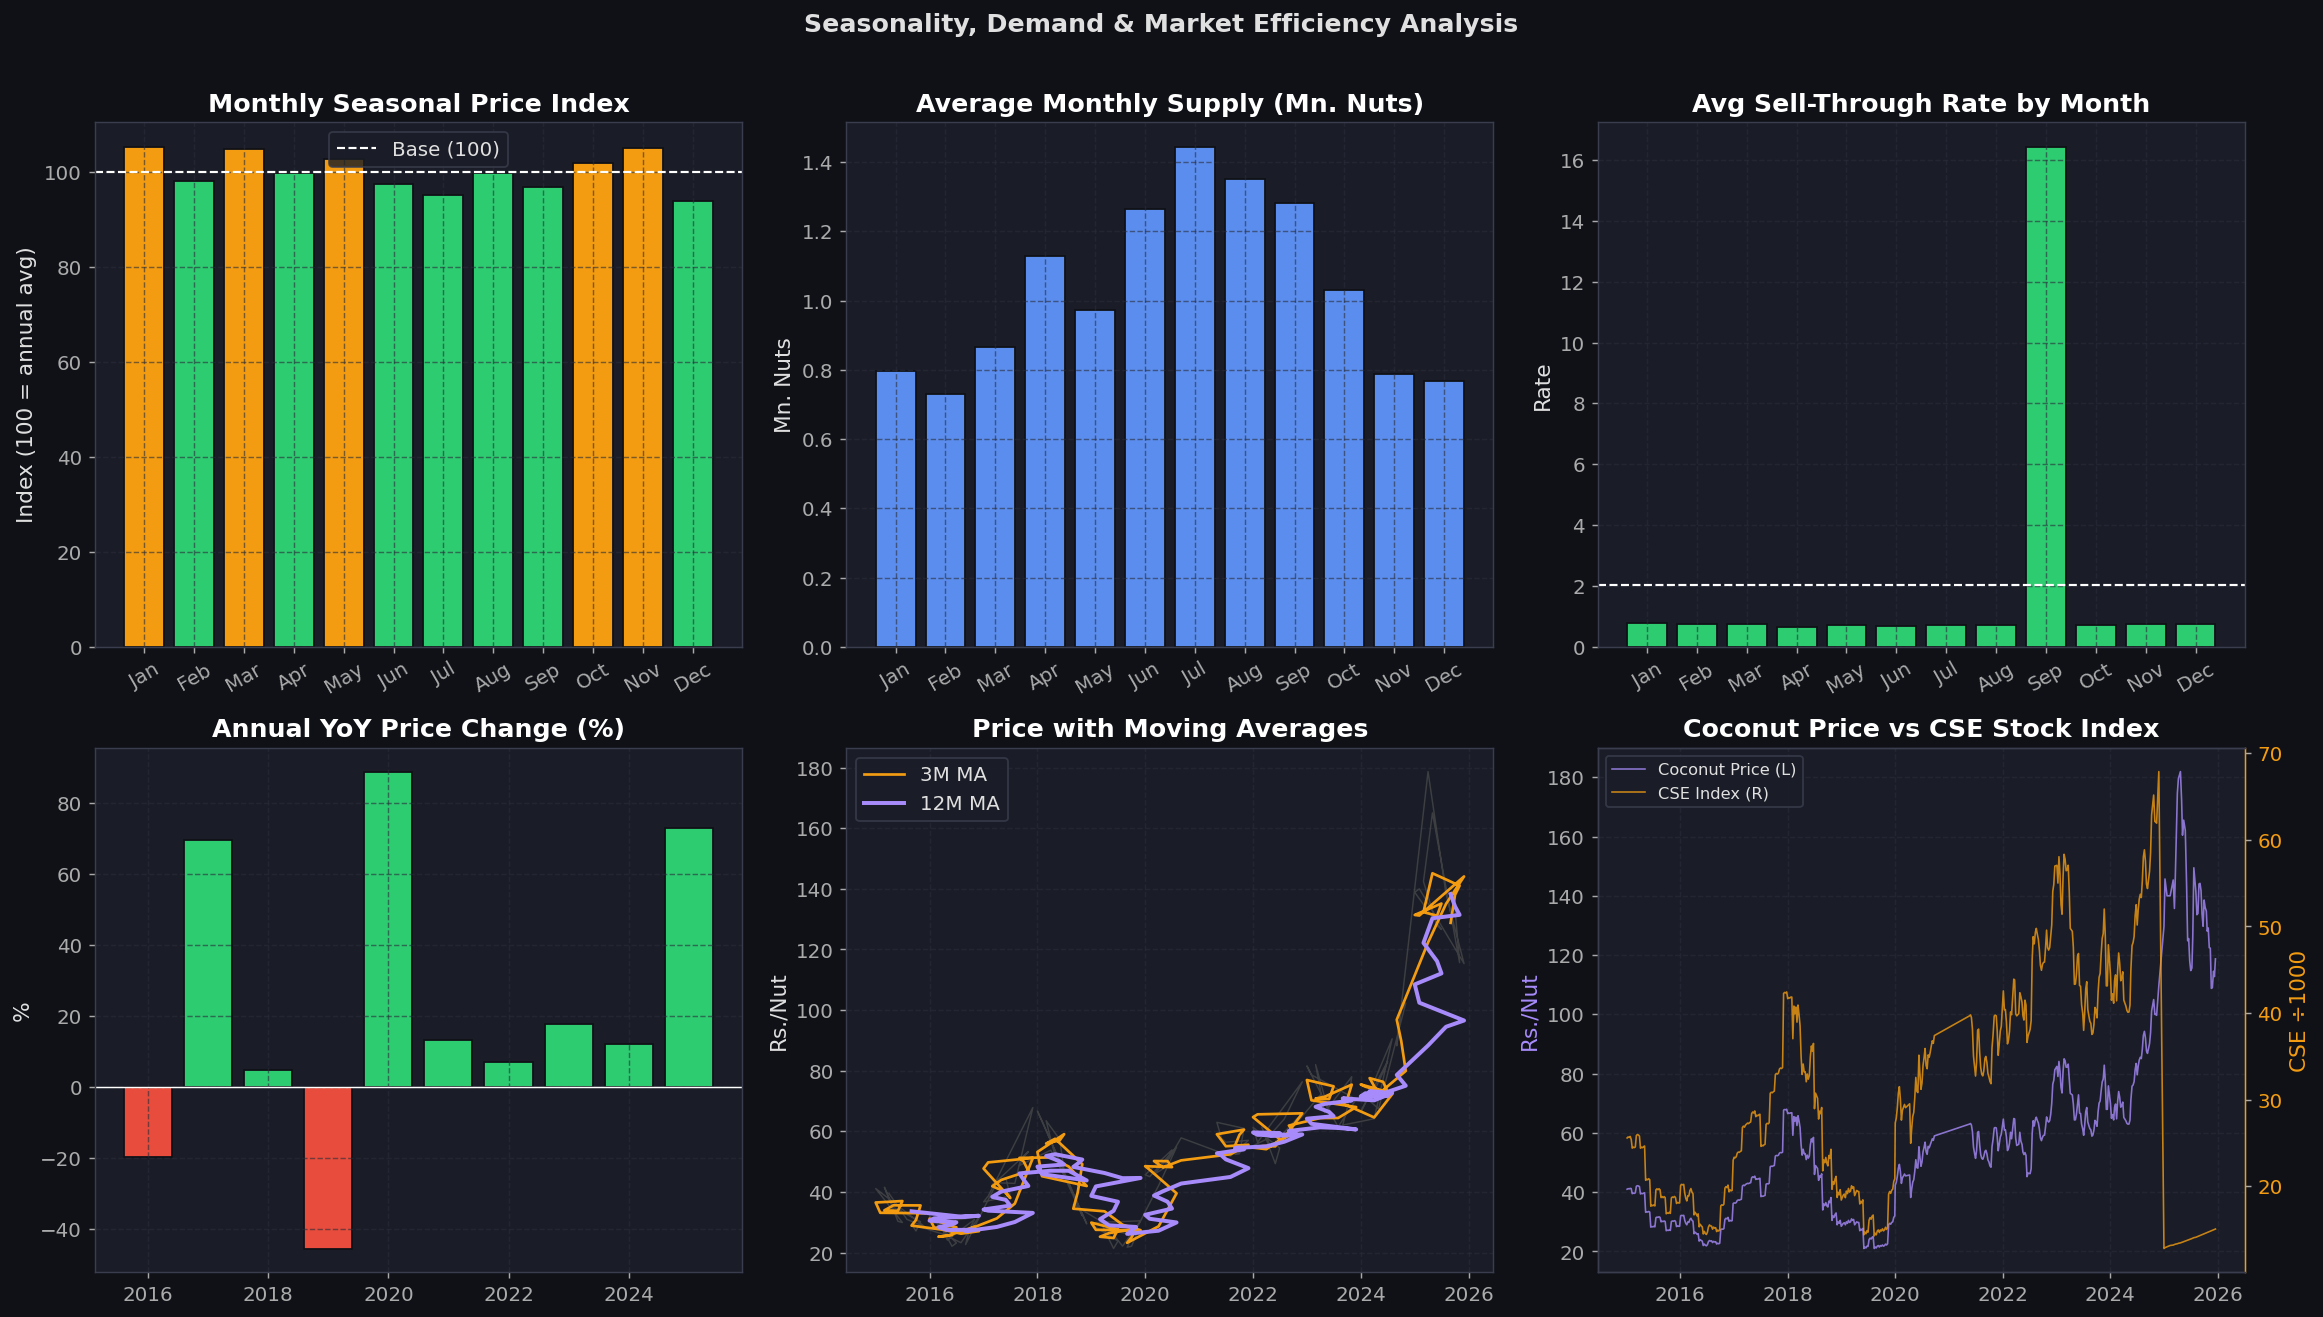

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Seasonality, Demand & Market Efficiency Analysis', fontsize=14, fontweight='bold', y=1.01)

months_s = seasonal.index

# 1. Seasonal price index
ax = axes[0,0]
clrs_s = ['#e74c3c' if v > 110 else '#f39c12' if v > 100 else '#2ecc71' for v in seasonal['Seasonal_Index']]
bars = ax.bar(months_s, seasonal['Seasonal_Index'], color=clrs_s, edgecolor='#0f1117')
ax.axhline(100, color='white', linewidth=1.2, linestyle='--', label='Base (100)')
ax.set_title('Monthly Seasonal Price Index', fontweight='bold')
ax.set_ylabel('Index (100 = annual avg)')
ax.legend()
ax.grid(True)
ax.tick_params(axis='x', rotation=30)

# 2. Avg supply by month
ax = axes[0,1]
ax.bar(months_s, seasonal['Avg_Offered']/1e6, color='#5b8dee', edgecolor='#0f1117')
ax.set_title('Average Monthly Supply (Mn. Nuts)', fontweight='bold')
ax.set_ylabel('Mn. Nuts')
ax.grid(True)
ax.tick_params(axis='x', rotation=30)

# 3. STR by month
ax = axes[0,2]
ax.bar(months_s, seasonal['Avg_STR'], color='#2ecc71', edgecolor='#0f1117')
ax.axhline(seasonal['Avg_STR'].mean(), color='white', linewidth=1.2, linestyle='--')
ax.set_title('Avg Sell-Through Rate by Month', fontweight='bold')
ax.set_ylabel('Rate')
ax.grid(True)
ax.tick_params(axis='x', rotation=30)

# 4. Annual YoY price change
ax = axes[1,0]
yoy = annual['YoY_Price_Change_%'].dropna()
bar_clrs = ['#2ecc71' if v > 0 else '#e74c3c' for v in yoy]
ax.bar(yoy.index, yoy.values, color=bar_clrs, edgecolor='#0f1117')
ax.axhline(0, color='white', linewidth=0.8)
ax.set_title('Annual YoY Price Change (%)', fontweight='bold')
ax.set_ylabel('%')
ax.grid(True)

# 5. Rolling 12M price trend
ax = axes[1,1]
roll12 = df_monthly.set_index('Date')['Avg_Price'].rolling(12).mean()
roll3  = df_monthly.set_index('Date')['Avg_Price'].rolling(3).mean()
ax.plot(df_monthly['Date'], df_monthly['Avg_Price']/1000, color='#555', linewidth=0.8, alpha=0.6)
ax.plot(roll3.index, roll3/1000, color='#f39c12', linewidth=1.5, label='3M MA')
ax.plot(roll12.index, roll12/1000, color='#a78bfa', linewidth=2.2, label='12M MA')
ax.set_title('Price with Moving Averages', fontweight='bold')
ax.set_ylabel('Rs./Nut')
ax.legend()
ax.grid(True)

# 6. CSE (stock market) vs price
wkly = df_weekly.copy()
wkly = wkly[pd.to_numeric(wkly['CSE'], errors='coerce').notna()].copy()
wkly['CSE'] = pd.to_numeric(wkly['CSE'])
wkly['Avg_Price_w'] = pd.to_numeric(wkly['Avg_Price'], errors='coerce')
wkly['Week_Date'] = pd.to_datetime(wkly['Week_Date'], errors='coerce')
wkly = wkly.dropna(subset=['CSE','Avg_Price_w','Week_Date']).sort_values('Week_Date')

ax = axes[1,2]
ax2 = ax.twinx()
ax.plot(wkly['Week_Date'], wkly['Avg_Price_w']/1000, color='#a78bfa', linewidth=0.9, alpha=0.8, label='Coconut Price (L)')
ax2.plot(wkly['Week_Date'], wkly['CSE']/1000, color='#f39c12', linewidth=0.9, alpha=0.8, label='CSE Index (R)')
ax.set_title('Coconut Price vs CSE Stock Index', fontweight='bold')
ax.set_ylabel('Rs./Nut', color='#a78bfa')
ax2.set_ylabel('CSE ÷1000', color='#f39c12')
ax2.tick_params(axis='y', labelcolor='#f39c12')
ax2.spines['right'].set_color('#f39c12')
l1,lb1 = ax.get_legend_handles_labels()
l2,lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.show()

---
## 12. Integrated Analytical Summary

In [50]:
# ── Regime transition matrix ──────────────────────────────────────────────────
regime_seq = clust_df['Regime'].values
transitions = pd.DataFrame(0, index=['Stable','Warning','Crisis'], columns=['Stable','Warning','Crisis'])
for i in range(len(regime_seq)-1):
    transitions.loc[regime_seq[i], regime_seq[i+1]] += 1

trans_prob = transitions.div(transitions.sum(axis=1), axis=0).round(4)

print('REGIME TRANSITION PROBABILITY MATRIX')
print('(Row = current regime, Column = next regime)')
print('=' * 55)
print(trans_prob.to_string())

print('\n\nREGIME TRANSITION COUNT MATRIX')
print('=' * 55)
print(transitions.to_string())

# ── Price summary per regime with elasticity ──────────────────────────────────
final_summary = reg_summary.copy()
final_summary['OLS_Elasticity'] = elas_df.set_index('Regime')['OLS_Elasticity']
final_summary['Elasticity_Type'] = elas_df.set_index('Regime')['Elasticity_Type']
final_summary['R_Squared'] = elas_df.set_index('Regime')['R_Squared']

print('\n\nCOMBINED REGIME PROFILE — CLUSTERING + ELASTICITY')
print('=' * 110)
print(final_summary.to_string())

# ── Forecast summary ──────────────────────────────────────────────────────────
print('\n\n12-MONTH FORECAST SUMMARY')
print('=' * 80)
print(f'  Model         : SARIMAX{best_order}x{best_sorder}')
print(f'  Forecast Mean : Rs. {fcast_mean.mean()/1000:.2f} per nut')
print(f'  Min Forecast  : Rs. {fcast_mean.min()/1000:.2f} per nut  (idx={fcast_mean.idxmin()})')
print(f'  Max Forecast  : Rs. {fcast_mean.max()/1000:.2f} per nut  (idx={fcast_mean.idxmax()})')
print(f'  Backtest MAPE : {mape:.2f}%')
print(f'  Backtest R²   : {r2:.4f}')
print()
print(final_forecast_table.to_string(index=False))

REGIME TRANSITION PROBABILITY MATRIX
(Row = current regime, Column = next regime)
         Stable  Warning  Crisis
Stable   0.8465   0.1491  0.0044
Warning  0.1675   0.8079  0.0246
Crisis   0.0000   0.0706  0.9294


REGIME TRANSITION COUNT MATRIX
         Stable  Warning  Crisis
Stable      193       34       1
Warning      34      164       5
Crisis        0        6      79


COMBINED REGIME PROFILE — CLUSTERING + ELASTICITY
         Count  Mean_Price  Std_Price  Min_Price  Max_Price  Mean_STR  Mean_Inflation  Mean_Volatility  Share_%  OLS_Elasticity Elasticity_Type  R_Squared
Regime                                                                                                                                                    
Crisis      85    73212.99   26635.02   45241.65  179497.23      0.73           39.18          3771.02     16.4         -1.3733         Elastic     0.5006
Stable     228    36953.97   12124.17   21000.00   68000.00      0.66            4.07           553.48  

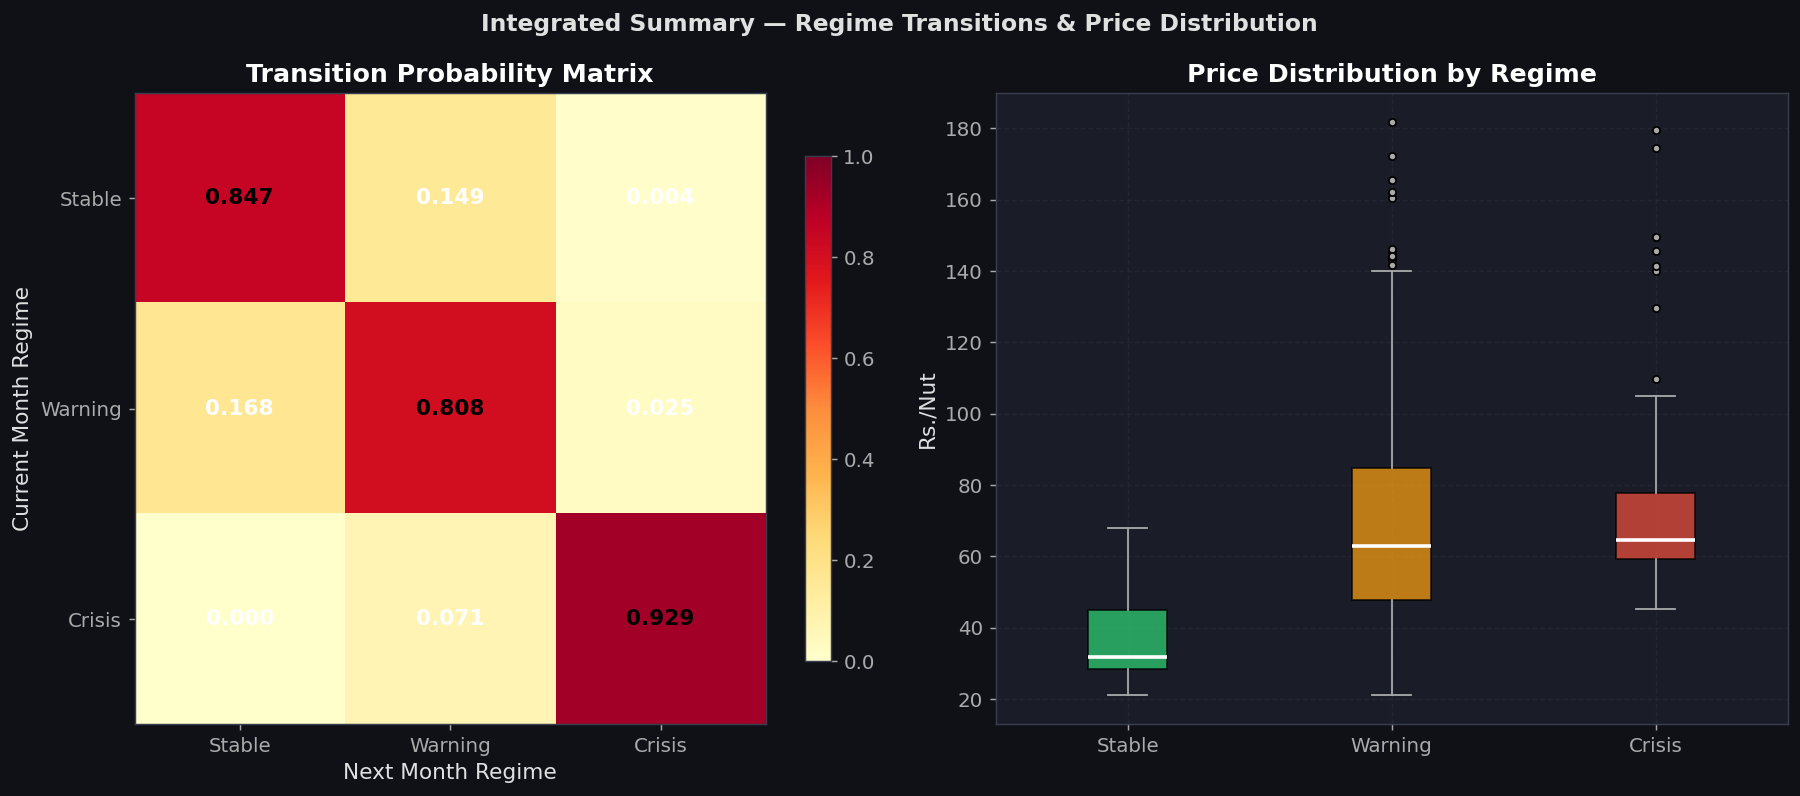

In [51]:
# ── Regime transition heatmap ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Integrated Summary — Regime Transitions & Price Distribution', fontsize=13, fontweight='bold')

ax = axes[0]
data_tp = trans_prob.values
im = ax.imshow(data_tp, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks([0,1,2]); ax.set_xticklabels(['Stable','Warning','Crisis'])
ax.set_yticks([0,1,2]); ax.set_yticklabels(['Stable','Warning','Crisis'])
ax.set_xlabel('Next Month Regime')
ax.set_ylabel('Current Month Regime')
ax.set_title('Transition Probability Matrix', fontweight='bold')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{data_tp[i,j]:.3f}', ha='center', va='center',
                fontsize=12, fontweight='bold', color='black' if data_tp[i,j] > 0.4 else 'white')
plt.colorbar(im, ax=ax, shrink=0.8)

# Box plot of price by regime
ax = axes[1]
data_bp = [clust_df.loc[clust_df['Regime']==r,'Avg_Price'].values/1000 for r in ['Stable','Warning','Crisis']]
bp = ax.boxplot(data_bp, labels=['Stable','Warning','Crisis'], patch_artist=True,
                medianprops={'color':'white','linewidth':2},
                whiskerprops={'color':'#aaa'},
                capprops={'color':'#aaa'},
                flierprops={'marker':'o','markerfacecolor':'#aaa','markersize':4})
for patch, regime in zip(bp['boxes'], ['Stable','Warning','Crisis']):
    patch.set_facecolor(PALETTE[regime])
    patch.set_alpha(0.75)
ax.set_title('Price Distribution by Regime', fontweight='bold')
ax.set_ylabel('Rs./Nut')
ax.grid(True)

plt.tight_layout()
plt.show()
